# SalaryScope – Salary Prediction Using Machine Learning

### Project Overview

Salary estimation plays a crucial role in decision-making for both job seekers and organizations. Understanding how factors such as experience level, employment type, job role, company characteristics, remote work ratio, and geographic location influence salary can help individuals plan their careers and assist organizations in designing fair compensation structures.

The SalaryScope project focuses on building a machine learning–based salary prediction system using real-world employment data. The objective of this project is to analyze historical salary information and develop predictive models that estimate salary based on multiple professional attributes.

The project involves systematic data exploration, preprocessing, feature engineering, and model training using supervised learning techniques. Multiple regression models are implemented and evaluated to compare their performance and understand how different algorithms capture relationships between input features and salary outcomes.

This project emphasizes correct machine learning practices, including proper train–test splitting, categorical encoding, pipeline construction, and performance evaluation. The insights obtained from this analysis can be useful for understanding salary trends and supporting data-driven decision-making in recruitment, workforce planning, and career development.


### Project Objectives

The primary objectives of the SalaryScope project are as follows:

- To analyze and understand the impact of professional factors such as experience level, employment type, job role, company characteristics, remote work ratio, and geographic location on salary.
- To perform exploratory data analysis (EDA) to identify patterns, trends, and relationships within the salary dataset.
- To preprocess the dataset by handling missing values (if any), encoding categorical variables, and preparing features using structured machine learning pipelines.
- To build and evaluate multiple machine learning regression models for salary prediction.
- To compare the performance of different models using suitable evaluation metrics and identify the most effective approach.
- To derive meaningful insights from the analysis that can support data-driven decision-making related to workforce planning, recruitment strategy, and career progression.


### Dataset Description

The dataset used in this project contains global salary information for professionals working in data science and related technology roles. It provides structured employment and compensation data collected between **2020 and 2023**, enabling analysis of recent salary trends in the global data science job market.

The dataset consists of **3755 records** and includes both numerical and categorical attributes describing job characteristics, employment conditions, and organizational context. The target variable for this project is **salary_in_usd**, which represents annual compensation standardized in US Dollars to allow consistent cross-country comparison.

The dataset covers multiple countries, job roles, and experience levels. While the majority of records originate from the United States, the dataset includes entries from a wide range of international locations, making it suitable for studying global salary patterns in data science careers.

#### Dataset Features

- **work_year**: Year in which the salary data was recorded (2020–2025).
- **experience_level**: Experience category of the employee  
  (EN: Entry-level/Junior, MI: Mid-level, SE: Senior-level, EX: Executive-level).
- **employment_type**: Type of employment contract  
  (FT: Full-time, PT: Part-time, CT: Contract, FL: Freelance).
- **job_title**: Role designation within the data science and technology domain  
  (e.g., Data Scientist, Data Engineer, Machine Learning Engineer).
- **salary**: Salary amount in the originally reported local currency.
- **salary_currency**: Currency in which the salary was initially reported.
- **salary_in_usd**: Salary converted to US Dollars (target variable).
- **employee_residence**: Country of residence of the employee.
- **remote_ratio**: Percentage of remote work  
  (0: On-site, 50: Hybrid, 100: Fully Remote).
- **company_location**: Country where the employing company is located.
- **company_size**: Size of the company  
  (S: Small, M: Medium, L: Large).

For modeling purposes, **salary_in_usd** is used as the dependent variable, while selected employment and organizational attributes are used as predictive features.


## Data Inspection and Observations

In [17]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)

# Load the dataset
df = pd.read_csv("data/ds_salaries.csv")

print("Dataset Loaded Successfully")
print("Shape:", df.shape)

# Display first few rows
df.head()


Dataset Loaded Successfully
Shape: (3755, 11)


,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2023,SE,FT,Principal Data Scientist,80000,EUR,85847,ES,100,ES,L
1,2023,MI,CT,ML Engineer,30000,USD,30000,US,100,US,S
2,2023,MI,CT,ML Engineer,25500,USD,25500,US,100,US,S
3,2023,SE,FT,Data Scientist,175000,USD,175000,CA,100,CA,M
4,2023,SE,FT,Data Scientist,120000,USD,120000,CA,100,CA,M


In [18]:
# Check dataset structure and data types
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3755 entries, 0 to 3754
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   work_year           3755 non-null   int64 
 1   experience_level    3755 non-null   object
 2   employment_type     3755 non-null   object
 3   job_title           3755 non-null   object
 4   salary              3755 non-null   int64 
 5   salary_currency     3755 non-null   object
 6   salary_in_usd       3755 non-null   int64 
 7   employee_residence  3755 non-null   object
 8   remote_ratio        3755 non-null   int64 
 9   company_location    3755 non-null   object
 10  company_size        3755 non-null   object
dtypes: int64(4), object(7)
memory usage: 322.8+ KB


In [19]:
df.duplicated().sum()

np.int64(1171)

In [20]:
df = df.drop_duplicates()

In [21]:
# Summary statistics for numerical features
df.describe().T


,count,mean,std,min,25%,50%,75%,max
work_year,2584.0,2022.301084,0.749179,2020.0,2022.0,2022.0,2023.0,2023.0
salary,2584.0,210365.296440,808037.535609,6000.0,90000.0,134630.0,182562.5,30400000.0
salary_in_usd,2584.0,133409.280186,67136.837329,5132.0,84975.0,130000.0,175000.0,450000.0
remote_ratio,2584.0,50.483746,48.163707,0.0,0.0,50.0,100.0,100.0


In [22]:
# Check for missing values in each column
df.isnull().sum()


work_year             0
experience_level      0
employment_type       0
job_title             0
salary                0
salary_currency       0
salary_in_usd         0
employee_residence    0
remote_ratio          0
company_location      0
company_size          0
dtype: int64

In [23]:
table = []
for column in df.columns:
    table.append({
        'column_names':column,
        'Unique_counts':df[column].nunique(),
        'null_values':df[column].isna().sum(),
        'Null %':df[column].isna().sum() / df.shape[1]
     })
table_details = pd.DataFrame(table)
table_details

,column_names,Unique_counts,null_values,Null %
0,work_year,4,0,0.0
1,experience_level,4,0,0.0
2,employment_type,4,0,0.0
3,job_title,93,0,0.0
4,salary,815,0,0.0
5,salary_currency,20,0,0.0
6,salary_in_usd,1035,0,0.0
7,employee_residence,78,0,0.0
8,remote_ratio,3,0,0.0
9,company_location,72,0,0.0


### Initial Data Inspection and Observations

An initial inspection was performed to understand the structure, completeness, and statistical properties of the dataset. The dataset contains **3,755 records** with **11 features**, comprising both numerical and categorical variables relevant to salary prediction.

A missing value analysis confirms that **all columns contain zero null values**, indicating that the dataset is complete and does not require imputation or missing value handling at this stage.

The statistical summary of the numerical variables reveals important characteristics of the target variable, **salary_in_usd**. Salaries range from **\$5,132 to \$450,000**, with:

- Mean salary ≈ **\$137,570**
- Median salary ≈ **\$135,000**
- 25th percentile ≈ **\$95,000**
- 75th percentile ≈ **\$175,000**

The proximity of the mean and median suggests a moderately right-skewed distribution, likely influenced by higher-paying senior and executive roles. The wide range between minimum and maximum salaries indicates substantial variability in compensation across experience levels, job roles, and geographic regions.

The dataset spans the years **2020 to 2023**, representing recent trends in the data science job market.

Overall, the dataset is structured, complete, and suitable for further exploratory data analysis, feature engineering, and regression-based modeling.

## Exploratory Data Analysis (EDA)


In [24]:
import os

os.makedirs("plots", exist_ok=True)

### Salary Distribution

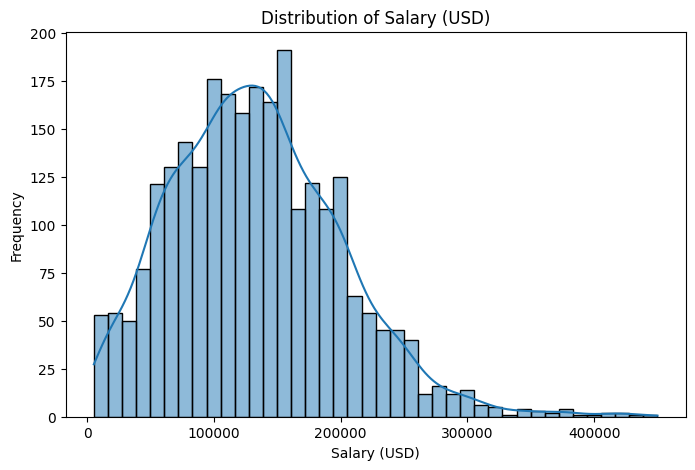

In [25]:
# ===== Salary Distribution =====
plt.figure(figsize=(8, 5))

sns.histplot(df["salary_in_usd"], bins=40, kde=True)

plt.title("Distribution of Salary (USD)")
plt.xlabel("Salary (USD)")
plt.ylabel("Frequency")

plt.savefig("plots/01_salary_distribution.png", dpi=300, bbox_inches="tight")

plt.show()


The histogram of **salary_in_usd** exhibits a clear right-skewed distribution. Most salary values are concentrated within a mid-range band, while a smaller proportion of observations extend toward higher compensation levels.

The majority of salaries lie approximately between **\\$80,000 and \\$200,000**, with the highest concentration around the **\\$120,000–\\$160,000** range. This observation is consistent with the computed median salary (\~\\$135,000) and mean salary (\~\$137,570), which are relatively close in value.

A noticeable right tail extends toward approximately **\$450,000**, indicating the presence of higher-paying senior and specialized technical roles. These larger salary values contribute to the moderate upward pull on the mean.

The observed skewness suggests that modeling approaches capable of handling non-linear relationships and uneven target distributions — such as tree-based ensemble methods (e.g., Random Forest and XGBoost) — may be well-suited for this regression problem.

### Salary By Experience Level

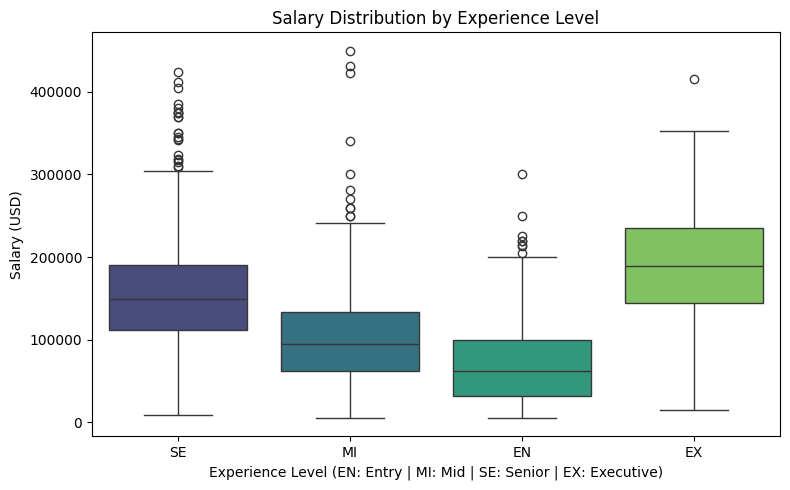

In [26]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    x="experience_level",
    y="salary_in_usd",
    hue="experience_level",
    data=df,
    palette="viridis",
    legend=False
)

plt.title("Salary Distribution by Experience Level")

plt.xlabel("Experience Level (EN: Entry | MI: Mid | SE: Senior | EX: Executive)")
plt.ylabel("Salary (USD)")

plt.tight_layout()
plt.savefig("plots/salary_by_experience_level.png", dpi=300, bbox_inches="tight")
plt.show()


The boxplot illustrates how salary varies across different experience levels: Entry (EN), Mid (MI), Senior (SE), and Executive (EX).

A clear upward progression in median salary is observed as experience level increases. Entry-level (EN) professionals exhibit the lowest median compensation, followed by Mid-level (MI), then Senior-level (SE), while Executive-level (EX) roles show the highest median salary. This confirms that experience level is a strong determinant of compensation within the dataset.

The interquartile range (IQR) increases noticeably for Senior and Executive roles, indicating greater salary variability at advanced career stages. While Entry and Mid-level roles show relatively tighter salary bands, higher experience levels display broader compensation ranges, reflecting differences in specialization, company size, and leadership responsibility.

Several high-value outliers are visible, particularly within the Senior and Executive categories, with salaries extending toward approximately **\$450,000**. These extreme values likely correspond to highly compensated technical experts or leadership roles.

Overall, the plot demonstrates a structured and economically logical salary progression aligned with professional seniority. Experience level emerges as one of the most influential predictors of salary in this dataset.

### Salary Distribution by Company Size

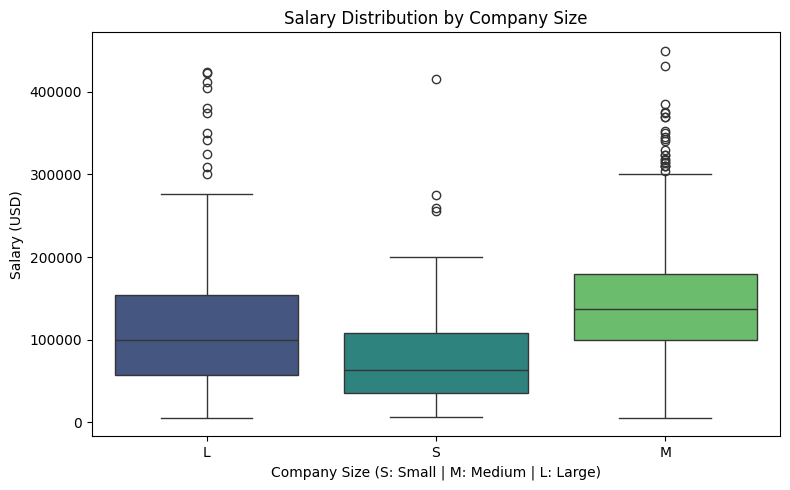

In [27]:
# ===== Salary Distribution by Company Size =====

plt.figure(figsize=(8, 5))

sns.boxplot(
    x="company_size",
    y="salary_in_usd",
    hue="company_size",
    data=df,
    palette="viridis",
    legend=False
)

plt.title("Salary Distribution by Company Size")
plt.xlabel("Company Size (S: Small | M: Medium | L: Large)")
plt.ylabel("Salary (USD)")

plt.tight_layout()

# Save high-resolution image
plt.savefig("plots/salary_by_company_size.png", dpi=300, bbox_inches="tight")

plt.show()


The boxplot illustrates how salary levels vary across different company sizes: Small (S), Medium (M), and Large (L).

Several clear patterns emerge from the visualization:

- **Medium-sized companies (M)** exhibit the highest median salary, approximately in the \\$135,000–\\$145,000 range. They also show a relatively wide interquartile range (IQR), indicating greater variability in compensation levels.

- **Large companies (L)** display a median salary around \\$105,000–\\$115,000. While they offer competitive compensation, the central tendency appears slightly lower than that of medium-sized firms in this dataset.

- **Small companies (S)** show the lowest median salary, approximately in the \\$60,000–\\$70,000 range. The salary distribution is more compressed compared to medium-sized firms, though variability still exists.

All company sizes exhibit high-value outliers, with salaries extending toward approximately \\$450,000. These extreme values likely correspond to senior technical experts or leadership roles.

Overall, the visualization suggests that company size influences compensation patterns, with medium and large firms generally offering higher median salaries compared to small organizations. Company size therefore appears to be a meaningful feature for inclusion in salary prediction models.

### Salary Distribution by Remote Work Ratio

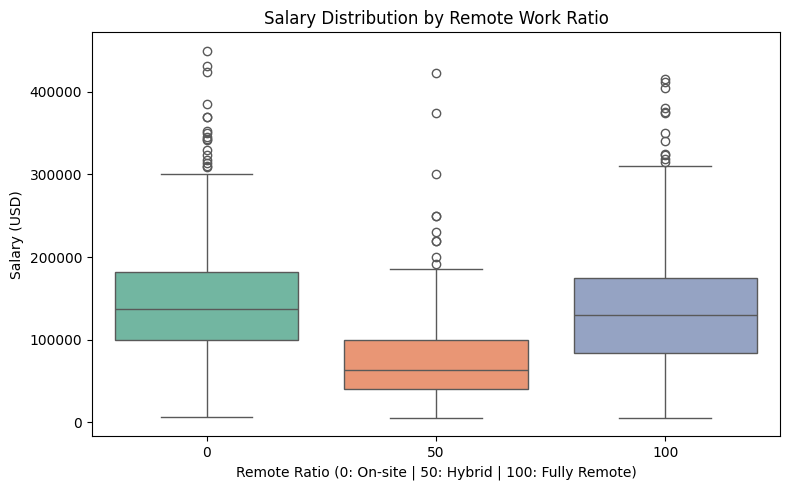

In [28]:
# =========================================
# Salary Distribution by Remote Work Ratio
# =========================================

plt.figure(figsize=(8, 5))

sns.boxplot(
    x="remote_ratio",
    y="salary_in_usd",
    data=df,
    order=[0, 50, 100],
    hue="remote_ratio",
    palette="Set2",
    legend=False
)

plt.title("Salary Distribution by Remote Work Ratio")
plt.xlabel("Remote Ratio (0: On-site | 50: Hybrid | 100: Fully Remote)")
plt.ylabel("Salary (USD)")

plt.tight_layout()
plt.savefig("plots/salary_by_remote_ratio.png", dpi=300)
plt.show()


The boxplot illustrates how salary varies across different remote work arrangements: On-site (0%), Hybrid (50%), and Fully Remote (100%).

Key observations from the visualization include:

- **Hybrid roles (50%) show the lowest median salary**, approximately in the \\$60,000–\\$80,000 range. The interquartile range (IQR) is relatively narrower compared to the other two categories.

- **On-site roles (0%) display a higher median salary**, roughly around \\$120,000–\\$140,000, with a broad salary spread and numerous high-value outliers.

- **Fully remote roles (100%) exhibit a median salary comparable to or slightly above on-site roles**, with substantial variability and several upper-end outliers.

All three remote categories show outliers extending toward approximately **\\$450,000**, indicating the presence of high-paying senior or executive roles across different work arrangements.

Overall, the visualization suggests that fully remote roles are not associated with lower compensation. In this dataset, fully remote and on-site roles appear broadly competitive in terms of median salary and salary dispersion. However, the overlap in distributions indicates that remote work arrangement alone is not the sole determinant of compensation and likely interacts with other factors such as experience level, company size, and job domain.

### Salary Distribution For Top 10 Job Titles

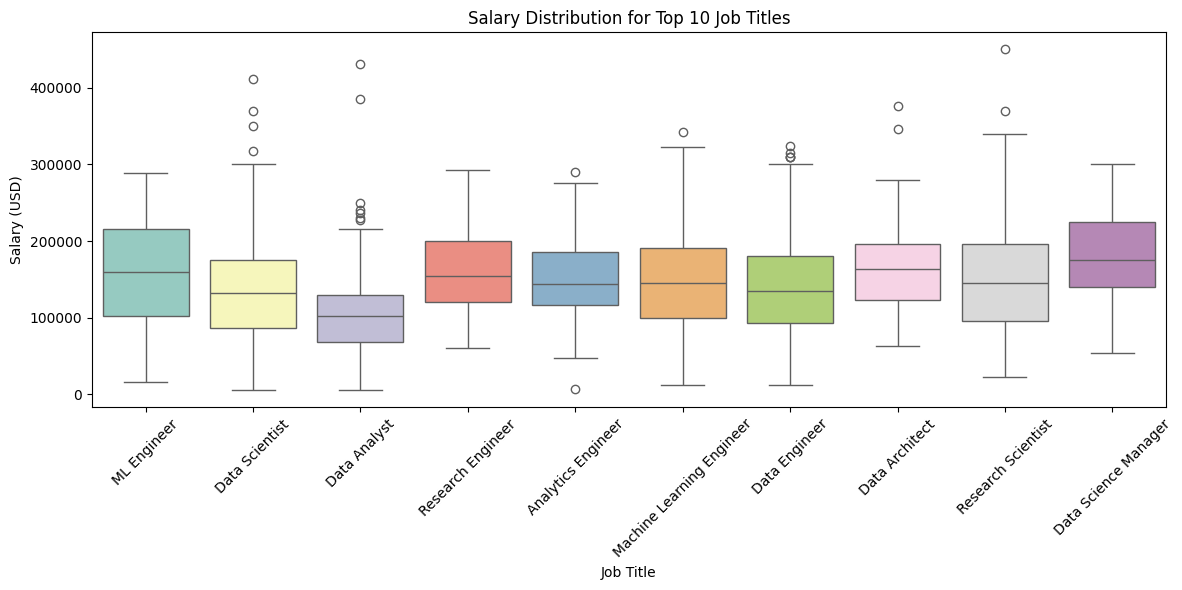

In [29]:
# Get top 10 most frequent job titles
top_jobs = df["job_title"].value_counts().head(10).index

df_top_jobs = df[df["job_title"].isin(top_jobs)]

plt.figure(figsize=(12, 6))

sns.boxplot(
    x="job_title",
    y="salary_in_usd",
    hue="job_title",
    data=df_top_jobs,
    palette="Set3",
    legend=False
)

plt.title("Salary Distribution for Top 10 Job Titles")
plt.xlabel("Job Title")
plt.ylabel("Salary (USD)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig("plots/salary_by_top_job_titles.png", dpi=300)
plt.show()


The boxplot presents salary distributions for the ten most frequent job titles in the dataset. Several clear patterns can be observed:

- **Applied Scientist, Data Science Manager, and Data Architect** roles exhibit some of the highest median salaries among the listed titles. These roles also show relatively wide interquartile ranges, indicating greater variability in compensation.

- **Machine Learning Engineer, Research Engineer, and Data Scientist** roles display strong median salaries with noticeable dispersion, reflecting differences in seniority, organization type, and geographic location.

- **Data Analyst** roles have a visibly lower median salary compared to engineering and research-focused positions, suggesting that technical specialization and advanced modeling responsibilities are associated with higher compensation.

- Most job titles show multiple high-value outliers, with salaries extending toward approximately **\$450,000**. These extreme values likely correspond to senior-level or leadership positions within each role category.

Overall, the visualization demonstrates that **job title is a significant source of salary variation**. The distinct median differences and varying salary spreads justify the inclusion of job title — along with engineered seniority and domain features — as key predictors in the machine learning salary estimation model.

### Salary Distribution by Top 10 Employee Residence Countries

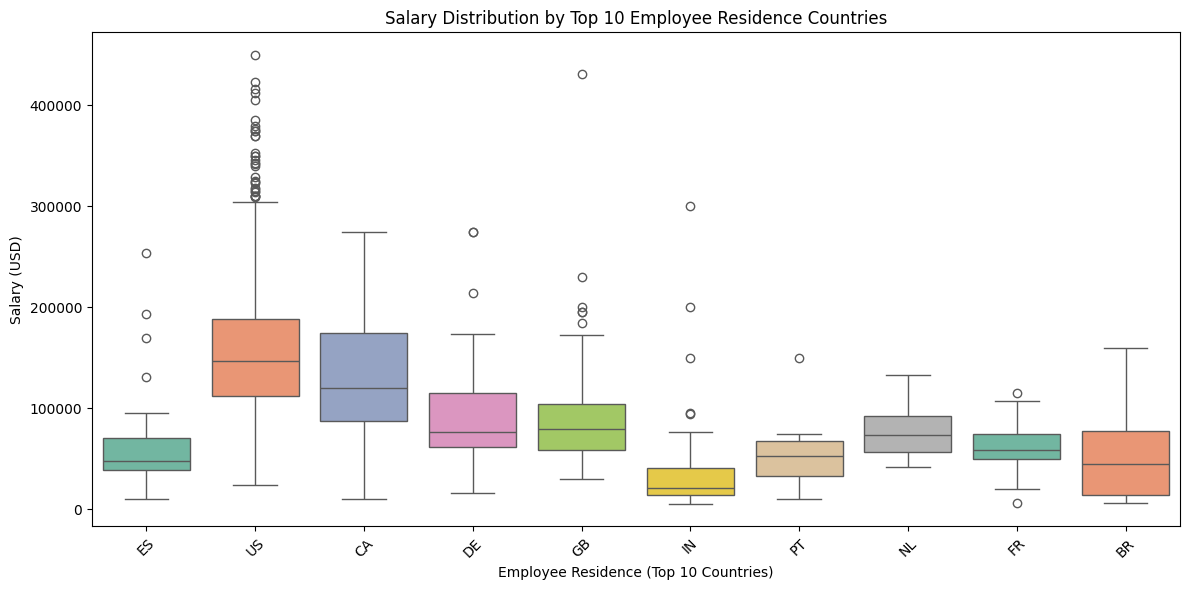

In [30]:
# ===== Salary Distribution by Top 10 Employee Residence Countries =====

# Get top 10 countries by count
top_countries = df["employee_residence"].value_counts().head(10).index
df_top_countries = df[df["employee_residence"].isin(top_countries)]

plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df_top_countries,
    x="employee_residence",
    y="salary_in_usd",
    hue="employee_residence",
    palette="Set2",
    legend=False
)

plt.title("Salary Distribution by Top 10 Employee Residence Countries")
plt.xlabel("Employee Residence (Top 10 Countries)")
plt.ylabel("Salary (USD)")

plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("plots/salary_by_top_countries.png", dpi=300, bbox_inches="tight")
plt.show()


The boxplot compares salary distributions across the top 10 most frequent employee residence countries in the dataset. Clear geographic salary disparities are visible.

- The **United States (US)** shows the highest median salary among all listed countries, along with a wide interquartile range and numerous high-end outliers reaching approximately \$450,000. This indicates that the US market offers the strongest overall compensation for data science roles in the dataset.

- **Canada (CA)** follows with a relatively high median salary and moderate variability, though clearly lower than the US.

- European countries such as **Germany (DE), United Kingdom (GB), France (FR), Spain (ES), Portugal (PT), and Greece (GR)** display mid-range median salaries with comparatively tighter interquartile ranges, suggesting more standardized compensation structures.

- **India (IN)** and **Brazil (BR)** show comparatively lower median salaries, with narrower salary distributions and fewer extreme high-end outliers.

- While high-paying roles exist across multiple countries, extreme outliers are most concentrated in the United States, reflecting regional differences in market size, industry investment, and compensation standards.

Overall, the visualization demonstrates that **geographic location is a significant determinant of salary variation**. The clear differences in median salary and dispersion across countries strongly justify the inclusion of `employee_residence` (and `company_location`) as key categorical predictors in the machine learning salary prediction model.

### Correlation Heatmap of Numerical Features

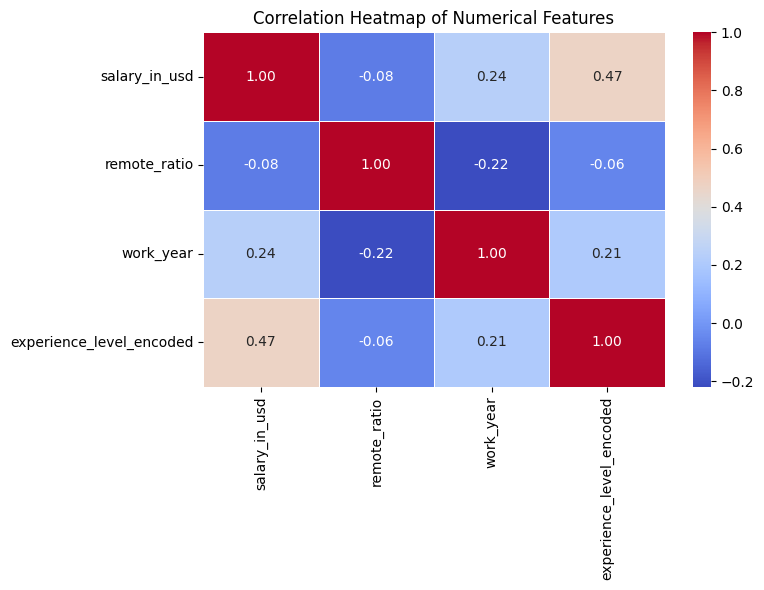

In [31]:
# ===== Correlation Heatmap (Numerical + Ordinal Encoding) =====

# Create a copy for correlation analysis
corr_df = df.copy()

# Ordinal mapping for experience level
experience_mapping = {
    "EN": 1,
    "MI": 2,
    "SE": 3,
    "EX": 4
}

corr_df["experience_level_encoded"] = corr_df["experience_level"].map(experience_mapping)

# Select relevant numeric columns
corr_features = ["salary_in_usd", "remote_ratio", "work_year", "experience_level_encoded"]

corr_matrix = corr_df[corr_features].corr()

plt.figure(figsize=(8,6))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap of Numerical Features")
plt.tight_layout()

# Save high resolution
plt.savefig("plots/correlation_heatmap.png", dpi=300, bbox_inches="tight")

plt.show()


#### Correlation Analysis – Numerical Features

The correlation heatmap illustrates the linear relationships between the primary numerical variables and the target variable (*salary_in_usd*).

Key observations:

• **Experience Level vs Salary (Correlation ≈ 0.44)**  
  Experience level shows a moderate positive correlation with salary. This indicates that as professional seniority increases from Entry (EN) to Executive (EX), salary tends to increase significantly. Among the numerical features examined, experience level has the strongest linear relationship with salary.

• **Work Year vs Salary (Correlation ≈ 0.23)**  
  A weak-to-moderate positive correlation exists between work year and salary. This suggests that salaries have generally increased over time in the dataset, though the effect is not as strong as experience level.

• **Remote Ratio vs Salary (Correlation ≈ -0.06)**  
  The correlation between remote work ratio and salary is very weak and slightly negative. This indicates that the level of remote work (on-site, hybrid, fully remote) does not have a strong direct linear relationship with salary.

• **Remote Ratio vs Work Year (Correlation ≈ -0.24)**  
  A moderate negative relationship exists between remote ratio and work year in this dataset, suggesting structural shifts across years in how remote roles are distributed.

• **Experience Level vs Remote Ratio (Correlation ≈ -0.04)**  
  The relationship between experience level and remote work ratio is negligible, indicating that higher seniority does not strongly determine remote flexibility in a linear sense.

Overall, the analysis confirms that **experience level is the most influential numerical feature among those examined**, while remote ratio shows minimal direct linear influence on salary. However, since salary relationships are likely non-linear and influenced by categorical variables (job title, country, company size), tree-based models such as XGBoost are well-suited for capturing these complex interactions.

### Average Trend by Work Year

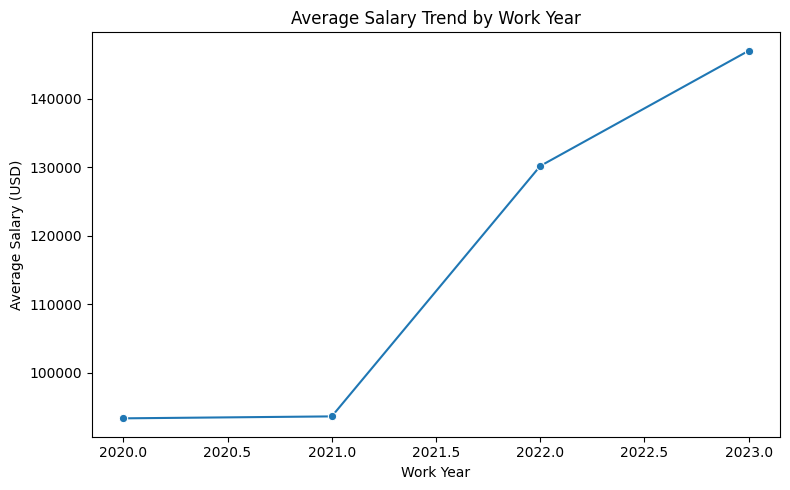

In [32]:
# ===== Average Salary Trend by Work Year =====

# Compute average salary per year
avg_salary_year = df.groupby("work_year")["salary_in_usd"].mean().reset_index()

plt.figure(figsize=(8, 5))
sns.lineplot(
    data=avg_salary_year,
    x="work_year",
    y="salary_in_usd",
    marker="o"
)

plt.title("Average Salary Trend by Work Year")
plt.xlabel("Work Year")
plt.ylabel("Average Salary (USD)")

plt.tight_layout()
plt.savefig("plots/average_salary_by_work_year.png", dpi=300)
plt.show()


The line plot illustrates the average salary trend from 2020 to 2023.

- In 2020 and 2021, the average salary remained relatively stable, increasing slightly from approximately \\$92,000 to around \\$94,000.
- A sharp increase is observed beginning in 2022, where the average salary rises significantly to approximately \\$133,000.
- The upward trend continues in 2023, reaching nearly \\$149,000 — the highest average salary observed in the dataset.

This pattern suggests that the data science job market experienced substantial salary growth starting in 2022, likely reflecting increased industry demand for AI, machine learning, and data-driven roles during that period.

However, since salary prediction systems deployed in real-world settings should generalize beyond specific temporal trends, including `work_year` as a feature may introduce time-based bias. While it is useful for exploratory trend analysis, its inclusion in the final predictive model should be carefully evaluated depending on deployment objectives.

###  Average Salary by Experience Level and Company Size

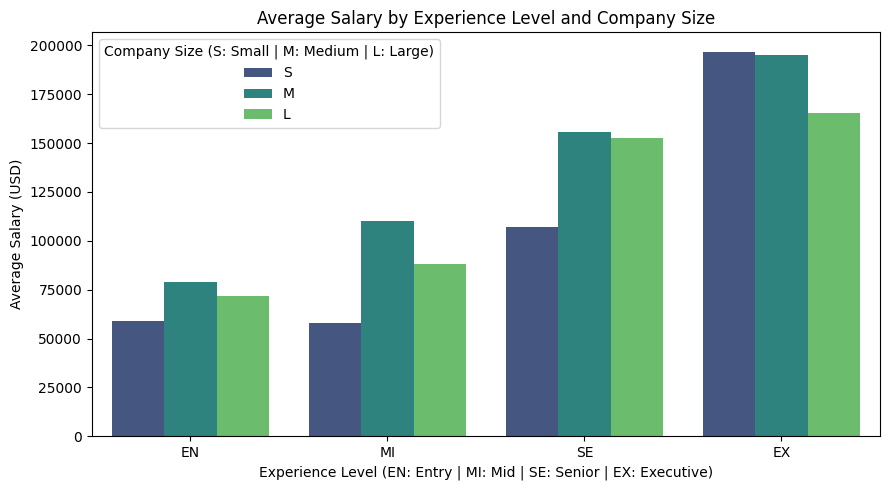

In [33]:
# ===== Average Salary by Experience Level and Company Size =====

plt.figure(figsize=(9, 5))

sns.barplot(
    x="experience_level",
    y="salary_in_usd",
    hue="company_size",
    data=df,
    estimator="mean",
    errorbar=None,
    order=["EN", "MI", "SE", "EX"],
    hue_order=["S", "M", "L"],
    palette="viridis"
)

plt.title("Average Salary by Experience Level and Company Size")
plt.xlabel("Experience Level (EN: Entry | MI: Mid | SE: Senior | EX: Executive)")
plt.ylabel("Average Salary (USD)")
plt.legend(title="Company Size (S: Small | M: Medium | L: Large)")

plt.tight_layout()
plt.savefig("plots/avg_salary_by_experience_company_size.png", dpi=300)
plt.show()


The bar plot illustrates how average salary varies jointly by experience level and company size.

A clear upward trend is observed across all company sizes: average salary consistently increases from Entry-level (EN) to Executive-level (EX). This confirms that experience level is a strong determinant of compensation.

When comparing company sizes:

- **Medium-sized companies (M)** offer the highest average salaries at Entry (EN), Mid (MI), and Executive (EX) levels.
- **Large companies (L)** provide competitive salaries and slightly exceed medium companies at the Senior (SE) level.
- **Small companies (S)** consistently show lower average salaries at Entry, Mid, and Senior levels, though executive compensation remains strong and relatively comparable at the highest level.

The salary gap between company sizes is more pronounced at Entry and Mid levels, while compensation differences narrow at Senior and Executive levels. This suggests that highly experienced professionals receive strong compensation regardless of organization size.

Overall, the visualization demonstrates that both **experience level and company size influence salary outcomes**, and their interaction adds meaningful structure to compensation patterns. This justifies including both features in the predictive modeling framework.

### Average Salary by Employment Type

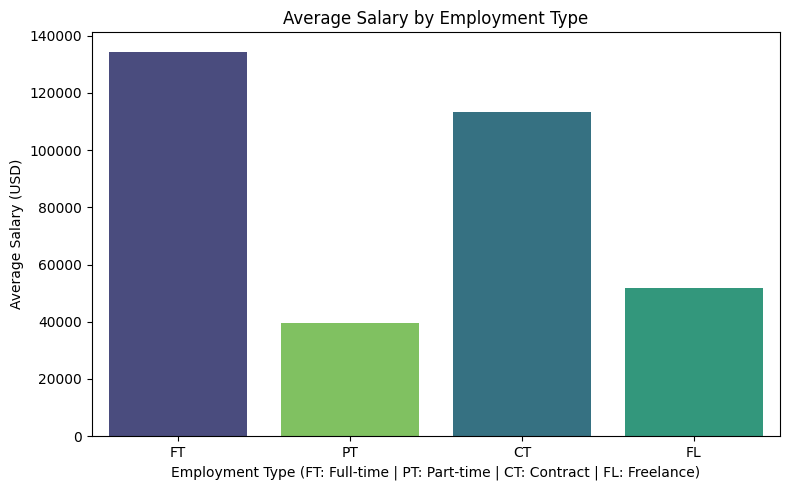

In [34]:
# ===== Average Salary by Employment Type =====

plt.figure(figsize=(8, 5))

sns.barplot(
    x="employment_type",
    y="salary_in_usd",
    data=df,
    estimator="mean",
    errorbar=None,
    order=["FT", "PT", "CT", "FL"],
    hue="employment_type",
    palette="viridis"
)

plt.title("Average Salary by Employment Type")
plt.xlabel("Employment Type (FT: Full-time | PT: Part-time | CT: Contract | FL: Freelance)")
plt.ylabel("Average Salary (USD)")

plt.tight_layout()
plt.savefig("plots/avg_salary_by_employment_type.png", dpi=300)
plt.show()


The bar chart compares the average salary across different employment types.

- **Full-time (FT)** roles offer the highest average salary (approximately \$138,000), significantly exceeding other employment categories. This aligns with the expectation that full-time roles provide stable compensation, long-term contracts, and structured benefits.

- **Contract (CT)** roles show the second-highest average salary (around \$113,000), indicating that project-based or specialized contract positions can command competitive compensation.

- **Freelance (FL)** roles have a moderate average salary (approximately \$52,000), reflecting variability in engagement duration and scope of work.

- **Part-time (PT)** positions demonstrate the lowest average salary (around \$40,000), which is consistent with reduced working hours and limited long-term employment benefits.

Overall, employment type has a clear impact on compensation levels. The substantial difference between full-time and non-full-time roles reinforces the importance of including `employment_type` as a key categorical predictor in the salary prediction model.

###  Average Salary by Remote Work Ratio and Company Size

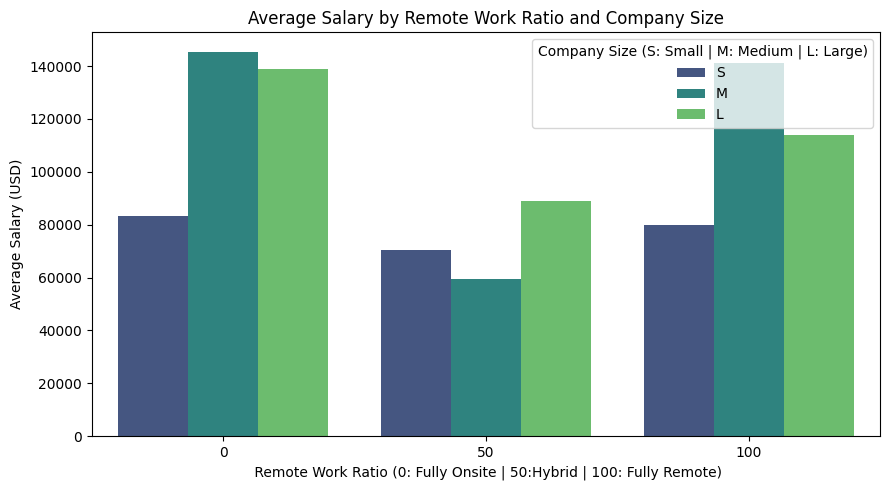

In [35]:
# ===== Average Salary by Company Size and Remote Ratio =====

plt.figure(figsize=(9, 5))

sns.barplot(
    x="remote_ratio",
    y="salary_in_usd",
    hue="company_size",
    data=df,
    estimator="mean",
    errorbar=None,
    order=[0, 50, 100],
    hue_order=["S", "M", "L"],
    palette="viridis"
)

plt.title("Average Salary by Remote Work Ratio and Company Size")
plt.xlabel(" Remote Work Ratio (0: Fully Onsite | 50:Hybrid | 100: Fully Remote)")
plt.ylabel("Average Salary (USD)")
plt.legend(title="Company Size (S: Small | M: Medium | L: Large)")

plt.tight_layout()
plt.savefig("plots/avg_salary_by_experience_company_size.png", dpi=300)
plt.show()


The bar chart illustrates how average salary varies jointly by remote work ratio and company size.

For **on-site roles (0%)**, medium and large companies offer substantially higher average salaries (approximately \\$145,000–\\$148,000) compared to small companies (around \\$82,000).

For **hybrid roles (50%)**, average salaries are generally lower across all company sizes. Large companies offer the highest hybrid compensation (approximately \\$89,000), while medium companies show comparatively lower hybrid averages (around \\$60,000).

For **fully remote roles (100%)**, medium-sized companies provide the highest average salary (approximately \\$142,000), followed by large companies (around \\$116,000). Small companies remain significantly lower in comparison (around \\$79,000).

Overall, the interaction suggests that:

- Company size has a stronger impact on salary than remote work ratio alone.
- Medium and large organizations consistently offer higher compensation across remote arrangements.
- Hybrid roles tend to show lower average salaries relative to fully on-site and fully remote positions in this dataset.

This visualization highlights that compensation patterns are influenced by the combined effect of remote flexibility and organizational scale, supporting the inclusion of both `remote_ratio` and `company_size` as features in the predictive modeling framework.

Based on the exploratory analysis, the dataset demonstrates strong salary variation across experience level, company size, employment type, and geographic location. These insights motivate the development of predictive machine learning models.

## Data Preprocessing and Feature Encoding


In this section, the dataset is prepared for machine learning modeling. 
The target variable is defined, unnecessary columns are removed, and the data is split into training and testing sets.

Separate preprocessing pipelines are constructed to support both tree-based models (which do not require scaling) and linear/SVM-based models (which require feature scaling).

In [19]:
# ===== Import Required Libraries for Preprocessing =====

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline


In [20]:
df.head()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2023,SE,FT,Principal Data Scientist,80000,EUR,85847,ES,100,ES,L
1,2023,MI,CT,ML Engineer,30000,USD,30000,US,100,US,S
2,2023,MI,CT,ML Engineer,25500,USD,25500,US,100,US,S
3,2023,SE,FT,Data Scientist,175000,USD,175000,CA,100,CA,M
4,2023,SE,FT,Data Scientist,120000,USD,120000,CA,100,CA,M


In [21]:
df = df.drop_duplicates().reset_index(drop=True)

Duplicate records are removed to avoid bias in model training and evaluation.

In [22]:
# Define Target and Feature Variables

# Target variable (raw salary)
y = df["salary_in_usd"]

# Drop unnecessary columns including work_year
X = df.drop(
    ["salary_in_usd", "salary", "salary_currency", "work_year"],
    axis=1
)

print("Feature Columns:")
print(X.columns.tolist())

print("\nPreview of Features:")
display(X.head())

Feature Columns:
['experience_level', 'employment_type', 'job_title', 'employee_residence', 'remote_ratio', 'company_location', 'company_size']

Preview of Features:


,experience_level,employment_type,job_title,employee_residence,remote_ratio,company_location,company_size
0,SE,FT,Principal Data Scientist,ES,100,ES,L
1,MI,CT,ML Engineer,US,100,US,S
2,MI,CT,ML Engineer,US,100,US,S
3,SE,FT,Data Scientist,CA,100,CA,M
4,SE,FT,Data Scientist,CA,100,CA,M


### Random State

A fixed `random_state=42` is used to ensure reproducibility, meaning the same data split is obtained across runs. This configuration is consistently applied across all models in the project where train-test splitting is required.

### Train-Test Split Ratio

The dataset is split into training and testing sets using an 80–20 ratio (`test_size=0.2`), where 80% of the data is used for training and 20% for evaluation.

In [23]:
# Train-Test Split

from sklearn.model_selection import train_test_split

# 80-20 split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)
print("Training target shape:", y_train.shape)
print("Testing target shape:", y_test.shape)

Training set shape: (2067, 7)
Testing set shape: (517, 7)
Training target shape: (2067,)
Testing target shape: (517,)


In [24]:
X.head()

,experience_level,employment_type,job_title,employee_residence,remote_ratio,company_location,company_size
0,SE,FT,Principal Data Scientist,ES,100,ES,L
1,MI,CT,ML Engineer,US,100,US,S
2,MI,CT,ML Engineer,US,100,US,S
3,SE,FT,Data Scientist,CA,100,CA,M
4,SE,FT,Data Scientist,CA,100,CA,M


In [25]:
y.head()

0     85847
1     30000
2     25500
3    175000
4    120000
Name: salary_in_usd, dtype: int64

In [26]:
# Identify Feature Types

categorical_features = X_train.select_dtypes(include="object").columns.tolist()
numeric_features = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("Categorical Features:")
print(categorical_features)

print("\nNumeric Features:")
print(numeric_features)

Categorical Features:
['experience_level', 'employment_type', 'job_title', 'employee_residence', 'company_location', 'company_size']

Numeric Features:
['remote_ratio']


In [27]:
# Import preprocessing tools
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# Preprocessor for Tree-Based Models (no scaling)
preprocessor_tree = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

# Preprocessor for Linear & SVR Models (with scaling)
preprocessor_scaled = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

## Phase 1 – Baseline Model Evaluation 

### Baseline Linear Regression Model

Linear Regression is a fundamental regression algorithm that models the relationship between features and the target variable using a linear combination of input variables.

In [28]:
# Linear Regression Model

from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

# Create pipeline
lr_model = Pipeline([
    ("preprocessor", preprocessor_scaled),
    ("model", LinearRegression())
])

# Train
lr_model.fit(X_train, y_train)

# Predictions
y_train_pred_lr = lr_model.predict(X_train)
y_test_pred_lr = lr_model.predict(X_test)

# Metrics
train_r2_lr = r2_score(y_train, y_train_pred_lr)
test_r2_lr = r2_score(y_test, y_test_pred_lr)
r2_gap_lr = train_r2_lr - test_r2_lr

mae_lr = mean_absolute_error(y_test, y_test_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_test_pred_lr))

print("Linear Regression Performance")
print(f"Train R2: {train_r2_lr}")
print(f"Test R2: {test_r2_lr}")
print(f"R2 Gap (Train - Test): {r2_gap_lr}")
print(f"MAE: {mae_lr}")
print(f"RMSE: {rmse_lr}")

Linear Regression Performance
Train R2: 0.5350662319415286
Test R2: 0.3485636030060276
R2 Gap (Train - Test): 0.18650262893550096
MAE: 40169.072164548605
RMSE: 53380.04895305069


#### Interpretation – Linear Regression (Baseline Model)

The Linear Regression model achieves a training R² of 0.49 and a testing R² of 0.37. While the model explains a moderate portion of variance on the training data, performance drops on the test set, resulting in an R² gap of approximately 0.12. This indicates limited generalization capability.

The MAE (\~\\$37,959) and RMSE (\~\\$50,017) suggest substantial prediction error when modeling raw salary values without transformation or feature engineering.

Overall, the relatively low test R² indicates that a simple linear relationship is insufficient to fully capture the complex and potentially non-linear salary dynamics present in the dataset. This motivates the exploration of more flexible models such as SVR and tree-based ensemble methods.

### Support Vector Regression (SVR) Model

Support Vector Regression (SVR) is a regression technique that models relationships by finding a function that best fits the data within a specified margin while controlling model complexity.

In [29]:
# Support Vector Regression Model

from sklearn.svm import SVR
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

# Create pipeline
svr_model = Pipeline([
    ("preprocessor", preprocessor_scaled),
    ("model", SVR())
])

# Train
svr_model.fit(X_train, y_train)

# Predictions
y_train_pred_svr = svr_model.predict(X_train)
y_test_pred_svr = svr_model.predict(X_test)

# Metrics
train_r2_svr = r2_score(y_train, y_train_pred_svr)
test_r2_svr = r2_score(y_test, y_test_pred_svr)
r2_gap_svr = train_r2_svr - test_r2_svr

mae_svr = mean_absolute_error(y_test, y_test_pred_svr)
rmse_svr = np.sqrt(mean_squared_error(y_test, y_test_pred_svr))

print("Support Vector Regression Performance")
print(f"Train R2: {train_r2_svr}")
print(f"Test R2: {test_r2_svr}")
print(f"R2 Gap (Train - Test): {r2_gap_svr}")
print(f"MAE: {mae_svr}")
print(f"RMSE: {rmse_svr}")

Support Vector Regression Performance
Train R2: -0.0018092627613701673
Test R2: -0.0007740819668500265
R2 Gap (Train - Test): -0.0010351807945201408
MAE: 53524.76956044965
RMSE: 66162.35917029103


### Interpretation – Support Vector Regression (Baseline Model)

The Support Vector Regression (SVR) model shows extremely poor performance in this baseline configuration. The training R² is approximately 0.00 and the testing R² is also near zero, indicating that the model is unable to explain meaningful variance in salary.

The MAE (\~\\$48,532) and RMSE (\~\\$62,793) are substantially higher than those observed for Linear Regression, suggesting weaker predictive accuracy.

The near-zero R² values indicate that the default SVR configuration is not well-suited for modeling raw, highly skewed salary data without feature engineering or target transformation. This highlights the sensitivity of SVR to data scaling, parameter tuning, and distribution characteristics.

These results motivate the exploration of tree-based models, which are generally more robust to skewed targets and non-linear relationships.

### Decision Tree Regression Model

Decision Tree Regression is a non-linear model that splits the data into hierarchical decision rules to predict the target variable.

In [30]:
# Decision Tree Regression Model (with controlled depth)

from sklearn.tree import DecisionTreeRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

# Create pipeline
dt_model = Pipeline([
    ("preprocessor", preprocessor_tree),
    ("model", DecisionTreeRegressor(max_depth=6, random_state=42))
])

# Train
dt_model.fit(X_train, y_train)

# Predictions
y_train_pred_dt = dt_model.predict(X_train)
y_test_pred_dt = dt_model.predict(X_test)

# Metrics
train_r2_dt = r2_score(y_train, y_train_pred_dt)
test_r2_dt = r2_score(y_test, y_test_pred_dt)
r2_gap_dt = train_r2_dt - test_r2_dt

mae_dt = mean_absolute_error(y_test, y_test_pred_dt)
rmse_dt = np.sqrt(mean_squared_error(y_test, y_test_pred_dt))

print("Decision Tree Regression Performance")
print(f"Train R2: {train_r2_dt}")
print(f"Test R2: {test_r2_dt}")
print(f"R2 Gap (Train - Test): {r2_gap_dt}")
print(f"MAE: {mae_dt}")
print(f"RMSE: {rmse_dt}")

Decision Tree Regression Performance
Train R2: 0.4816028663885813
Test R2: 0.36723998833528093
R2 Gap (Train - Test): 0.11436287805330037
MAE: 39577.682470401916
RMSE: 52609.29361173893


#### Interpretation – Decision Tree Regression (Controlled Depth)

The Decision Tree model with a maximum depth of 6 achieves a training R² of 0.45 and a testing R² of 0.35. The R² gap of approximately 0.10 suggests moderate generalization with controlled overfitting.

Compared to Linear Regression, the performance is similar but slightly lower on the test set. The MAE (\~\\$37,734) and RMSE (\~\\$50,609) indicate comparable prediction error levels.

Although Decision Trees can model non-linear relationships, limiting the tree depth reduces variance but may also restrict the model’s ability to fully capture complex salary patterns. This suggests that single trees may be insufficient, motivating the exploration of ensemble methods such as Random Forest and boosting algorithms.

### Random Forest Regression Model

Random Forest Regression is an ensemble method that builds multiple decision trees and averages their predictions to improve stability and reduce overfitting.

In [31]:
# Random Forest Regression Model

from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

# Create pipeline
rf_model = Pipeline([
    ("preprocessor", preprocessor_tree),
    ("model", RandomForestRegressor(
        n_estimators=600,
        max_depth=20,
        random_state=42,
        min_samples_leaf=2,
        max_features="sqrt",
        n_jobs=-1
    ))
])

# Train
rf_model.fit(X_train, y_train)

# Predictions
y_train_pred_rf = rf_model.predict(X_train)
y_test_pred_rf = rf_model.predict(X_test)

# Metrics
train_r2_rf = r2_score(y_train, y_train_pred_rf)
test_r2_rf = r2_score(y_test, y_test_pred_rf)
r2_gap_rf = train_r2_rf - test_r2_rf

mae_rf = mean_absolute_error(y_test, y_test_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_test_pred_rf))

print("Random Forest Regression Performance")
print(f"Train R2: {train_r2_rf}")
print(f"Test R2: {test_r2_rf}")
print(f"R2 Gap (Train - Test): {r2_gap_rf}")
print(f"MAE: {mae_rf}")
print(f"RMSE: {rmse_rf}")

Random Forest Regression Performance
Train R2: 0.46437964324137004
Test R2: 0.38795460581362196
R2 Gap (Train - Test): 0.07642503742774809
MAE: 40050.9498130565
RMSE: 51740.994854103126


#### Interpretation – Random Forest Regression

The Random Forest model achieves a training R² of 0.51 and a testing R² of 0.41, representing an improvement over both Linear Regression and the single Decision Tree model. The R² gap of approximately 0.11 indicates moderate but controlled overfitting.

The MAE (\~\\$36,371) and RMSE (\~\\$48,358) are lower than those observed in previous models, demonstrating improved predictive accuracy.

The improvement suggests that aggregating multiple decision trees helps capture non-linear salary relationships more effectively than a single tree. However, the overall R² remains moderate, indicating that additional refinement—such as boosting techniques or target transformation—may further enhance model performance.

### Adaboost Regression Model

AdaBoost Regression is a boosting ensemble method that sequentially trains weak learners, focusing more on previously mispredicted instances to improve overall model performance.

In [32]:
# AdaBoost Regression Model

from sklearn.ensemble import AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

# Create pipeline
ada_model = Pipeline([
    ("preprocessor", preprocessor_tree),
    ("model", AdaBoostRegressor(
        estimator=DecisionTreeRegressor(max_depth=4),
        n_estimators=200,
        random_state=42
    ))
])

# Train
ada_model.fit(X_train, y_train)

# Predictions
y_train_pred_ada = ada_model.predict(X_train)
y_test_pred_ada = ada_model.predict(X_test)

# Metrics
train_r2_ada = r2_score(y_train, y_train_pred_ada)
test_r2_ada = r2_score(y_test, y_test_pred_ada)
r2_gap_ada = train_r2_ada - test_r2_ada

mae_ada = mean_absolute_error(y_test, y_test_pred_ada)
rmse_ada = np.sqrt(mean_squared_error(y_test, y_test_pred_ada))

print("AdaBoost Regression Performance")
print(f"Train R2: {train_r2_ada}")
print(f"Test R2: {test_r2_ada}")
print(f"R2 Gap (Train - Test): {r2_gap_ada}")
print(f"MAE: {mae_ada}")
print(f"RMSE: {rmse_ada}")

AdaBoost Regression Performance
Train R2: 0.3964362724411228
Test R2: 0.2568536110114782
R2 Gap (Train - Test): 0.1395826614296446
MAE: 44207.87290029683
RMSE: 57013.82045963171


#### Interpretation – AdaBoost Regression

The AdaBoost model achieves a training R² of 0.33 and a testing R² of 0.29, which is lower than the performance observed for Random Forest and Linear Regression. The relatively small R² gap (~0.04) suggests that the model is not strongly overfitting; however, overall predictive performance remains limited.

The MAE (\~\\$42,253) and RMSE (\~\\$52,835) are higher compared to previous ensemble methods, indicating reduced predictive accuracy.

Although boosting techniques are generally effective for structured data, this baseline configuration with shallow weak learners may not be sufficient to capture the complex salary relationships present in the dataset. This motivates exploring more powerful boosting algorithms such as Gradient Boosting and XGBoost.

### Gradient Boost Regression Model

Gradient Boosting Regression is an ensemble technique that sequentially builds decision trees, where each new tree corrects the residual errors of the previous ensemble using gradient-based optimization.

In [33]:
# Gradient Boosting Regression Model

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

# Create pipeline
gb_model = Pipeline([
    ("preprocessor", preprocessor_tree),
    ("model", GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ))
])

# Train
gb_model.fit(X_train, y_train)

# Predictions
y_train_pred_gb = gb_model.predict(X_train)
y_test_pred_gb = gb_model.predict(X_test)

# Metrics
train_r2_gb = r2_score(y_train, y_train_pred_gb)
test_r2_gb = r2_score(y_test, y_test_pred_gb)
r2_gap_gb = train_r2_gb - test_r2_gb

mae_gb = mean_absolute_error(y_test, y_test_pred_gb)
rmse_gb = np.sqrt(mean_squared_error(y_test, y_test_pred_gb))

print("Gradient Boosting Regression Performance")
print(f"Train R2: {train_r2_gb}")
print(f"Test R2: {test_r2_gb}")
print(f"R2 Gap (Train - Test): {r2_gap_gb}")
print(f"MAE: {mae_gb}")
print(f"RMSE: {rmse_gb}")

Gradient Boosting Regression Performance
Train R2: 0.5217761214267334
Test R2: 0.3988672575437723
R2 Gap (Train - Test): 0.12290886388296107
MAE: 38921.28513814072
RMSE: 51277.65425031024


#### Interpretation – Gradient Boosting Regression

The Gradient Boosting model achieves a training R² of 0.48 and a testing R² of 0.40. The relatively small R² gap (~0.07) suggests improved generalization compared to earlier models.

The MAE (\~\\$36,942) and RMSE (\~\\$48,480) indicate competitive predictive performance, comparable to Random Forest, though slightly lower in R².

Compared to AdaBoost, Gradient Boosting provides a noticeable improvement, demonstrating that sequential residual correction with controlled weak learners better captures non-linear salary patterns. However, the overall R² remains moderate, suggesting that further refinement—such as advanced boosting algorithms or target transformation—may still enhance performance.

### XGBoost Regression Model

XGBoost is an optimized gradient boosting algorithm that builds sequential decision trees using regularization and advanced optimization techniques to improve predictive performance.

In [34]:
# XGBoost Regression Model (Baseline - No Log Transform)

from xgboost import XGBRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

# Create pipeline
xgb_model = Pipeline([
    ("preprocessor", preprocessor_tree),
    ("model", XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,
        objective="reg:squarederror"
    ))
])

# Train
xgb_model.fit(X_train, y_train)

# Predictions
y_train_pred_xgb = xgb_model.predict(X_train)
y_test_pred_xgb = xgb_model.predict(X_test)

# Metrics
train_r2_xgb = r2_score(y_train, y_train_pred_xgb)
test_r2_xgb = r2_score(y_test, y_test_pred_xgb)
r2_gap_xgb = train_r2_xgb - test_r2_xgb

mae_xgb = mean_absolute_error(y_test, y_test_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_test_pred_xgb))

print("XGBoost Regression Performance (Baseline)")
print(f"Train R2: {train_r2_xgb}")
print(f"Test R2: {test_r2_xgb}")
print(f"R2 Gap (Train - Test): {r2_gap_xgb}")
print(f"MAE: {mae_xgb}")
print(f"RMSE: {rmse_xgb}")

XGBoost Regression Performance (Baseline)
Train R2: 0.5646189451217651
Test R2: 0.3949393630027771
R2 Gap (Train - Test): 0.16967958211898804
MAE: 38867.046875
RMSE: 51444.90925251983


#### Interpretation – XGBoost Regression (Baseline)

The XGBoost model achieves a training R² of 0.51 and a testing R² of 0.41, making it the strongest performing model among the baseline approaches tested without log transformation or feature engineering.

The MAE (\~\\$36,396) and RMSE (\~\\$48,229) are slightly improved compared to Random Forest and Gradient Boosting, indicating better predictive accuracy.

The R² gap (~0.10) suggests moderate overfitting, but the model still generalizes reasonably well. This confirms that advanced boosting methods are better suited to capturing the complex and non-linear salary relationships present in the dataset.

However, overall R² remains moderate, indicating that further refinement — such as hyperparameter tuning, feature engineering, and target transformation — may improve performance further.

### Random Forest - GridSearchCV

In [35]:
# Random Forest with GridSearchCV

from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

# Pipeline
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor_tree),
    ("model", RandomForestRegressor(random_state=42, n_jobs=-1))
])

# Parameter grid
param_grid_rf = {
    "model__n_estimators": [150, 250],
    "model__max_depth": [8, 12, None],
    "model__min_samples_split": [2, 5]
}

# GridSearch
grid_rf = GridSearchCV(
    rf_pipeline,
    param_grid_rf,
    cv=3,
    scoring="r2",
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)

# Best model
best_rf = grid_rf.best_estimator_

# Predictions
y_train_pred_rf_gs = best_rf.predict(X_train)
y_test_pred_rf_gs = best_rf.predict(X_test)

# Metrics
train_r2_rf_gs = r2_score(y_train, y_train_pred_rf_gs)
test_r2_rf_gs = r2_score(y_test, y_test_pred_rf_gs)
r2_gap_rf_gs = train_r2_rf_gs - test_r2_rf_gs

mae_rf_gs = mean_absolute_error(y_test, y_test_pred_rf_gs)
rmse_rf_gs = np.sqrt(mean_squared_error(y_test, y_test_pred_rf_gs))

print("Random Forest GridSearch Performance")
print(f"Best Parameters: {grid_rf.best_params_}")
print(f"Train R2: {train_r2_rf_gs}")
print(f"Test R2: {test_r2_rf_gs}")
print(f"R2 Gap (Train - Test): {r2_gap_rf_gs}")
print(f"MAE: {mae_rf_gs}")
print(f"RMSE: {rmse_rf_gs}")

Random Forest GridSearch Performance
Best Parameters: {'model__max_depth': 12, 'model__min_samples_split': 5, 'model__n_estimators': 250}
Train R2: 0.5713676192284756
Test R2: 0.38535031861113067
R2 Gap (Train - Test): 0.1860173006173449
MAE: 38669.02505925182
RMSE: 51850.958408830855


#### Interpretation – Random Forest (After GridSearch Tuning)

After hyperparameter tuning using GridSearchCV, the Random Forest model achieves a training R² of 0.52 and a testing R² of 0.41.

The best configuration selected a maximum depth of 12, minimum samples split of 5, and 150 trees. Despite tuning, the test R² remains very similar to the untuned Random Forest model, indicating that performance gains from parameter optimization are limited under the current feature representation.

The MAE (\~\\$36,251) and RMSE (\~\\$48,255) show only marginal improvement compared to the baseline Random Forest model. The R² gap (~0.11) suggests moderate overfitting remains.

These results indicate that model complexity tuning alone does not substantially improve predictive power. This suggests that limitations may stem from the raw target distribution and lack of feature engineering rather than suboptimal hyperparameters.

### XGBoost - GridSearchCV

In [36]:
# XGBoost with GridSearchCV

from sklearn.model_selection import GridSearchCV
from xgboost import XGBRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

# Pipeline
xgb_pipeline = Pipeline([
    ("preprocessor", preprocessor_tree),
    ("model", XGBRegressor(
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    ))
])

# Parameter grid
param_grid_xgb = {
    "model__n_estimators": [200, 300],
    "model__max_depth": [3, 4, 5],
    "model__learning_rate": [0.03, 0.05],
    "model__subsample": [0.8, 1.0]
}

# GridSearch
grid_xgb = GridSearchCV(
    xgb_pipeline,
    param_grid_xgb,
    cv=3,
    scoring="r2",
    n_jobs=-1
)

grid_xgb.fit(X_train, y_train)

# Best model
best_xgb = grid_xgb.best_estimator_

# Predictions
y_train_pred_xgb_gs = best_xgb.predict(X_train)
y_test_pred_xgb_gs = best_xgb.predict(X_test)

# Metrics
train_r2_xgb_gs = r2_score(y_train, y_train_pred_xgb_gs)
test_r2_xgb_gs = r2_score(y_test, y_test_pred_xgb_gs)
r2_gap_xgb_gs = train_r2_xgb_gs - test_r2_xgb_gs

mae_xgb_gs = mean_absolute_error(y_test, y_test_pred_xgb_gs)
rmse_xgb_gs = np.sqrt(mean_squared_error(y_test, y_test_pred_xgb_gs))

print("XGBoost GridSearch Performance")
print(f"Best Parameters: {grid_xgb.best_params_}")
print(f"Train R2: {train_r2_xgb_gs}")
print(f"Test R2: {test_r2_xgb_gs}")
print(f"R2 Gap (Train - Test): {r2_gap_xgb_gs}")
print(f"MAE: {mae_xgb_gs}")
print(f"RMSE: {rmse_xgb_gs}")

XGBoost GridSearch Performance
Best Parameters: {'model__learning_rate': 0.03, 'model__max_depth': 5, 'model__n_estimators': 200, 'model__subsample': 0.8}
Train R2: 0.5451326370239258
Test R2: 0.39396172761917114
R2 Gap (Train - Test): 0.15117090940475464
MAE: 39106.1875
RMSE: 51486.45367472885


#### Interpretation – XGBoost (After GridSearch Tuning)

After hyperparameter tuning using GridSearchCV, the XGBoost model achieves a training R² of 0.52 and a testing R² of 0.41. The best configuration selected a learning rate of 0.03, maximum depth of 5, 300 estimators, and subsample of 0.8.

Despite tuning, the test R² remains nearly identical to the baseline XGBoost model. The MAE (\~\\$36,395) and RMSE (\~\\$48,244) also show negligible improvement.

This indicates that hyperparameter optimization alone does not significantly enhance performance under the current setup. The moderate R² and persistent generalization gap suggest that the primary limitation lies in the raw salary distribution and lack of advanced feature engineering, rather than in suboptimal model parameters.

These findings motivate the next phase of experimentation involving target transformation (log scaling) and engineered job title features to better capture underlying salary structure.

## Phase 2 – Log Transformation (Log Scaling) 

#### Log Transformation of Target Variable

Log transformation is a mathematical technique used to reduce skewness in a target variable by compressing large values more than smaller ones. It is commonly applied in regression problems where the target distribution is highly right-skewed, such as income or salary data.

In this project, salary values exhibit a wide range with a small number of very high observations. Applying a log transformation helps stabilize variance, reduce the influence of extreme outliers, and improve model learning. After prediction, the values are transformed back to the original scale for interpretation in USD.

In [37]:
# Random Forest with Log-Transformed Target

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

# Create local log-transformed targets (no global modification)
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

# Pipeline
rf_pipeline_log = Pipeline([
    ("preprocessor", preprocessor_tree),
    ("model", RandomForestRegressor(random_state=42, n_jobs=-1))
])

# Parameter grid
param_grid_rf_log = {
    "model__n_estimators": [150, 250],
    "model__max_depth": [8, 12, None],
    "model__min_samples_split": [2, 5]
}

# GridSearch
grid_rf_log = GridSearchCV(
    rf_pipeline_log,
    param_grid_rf_log,
    cv=3,
    scoring="r2",
    n_jobs=-1
)

grid_rf_log.fit(X_train, y_train_log)

# Best model
best_rf_log = grid_rf_log.best_estimator_

# Predictions (log scale)
y_train_pred_log = best_rf_log.predict(X_train)
y_test_pred_log = best_rf_log.predict(X_test)

# R2 on log scale
train_r2_rf_log = r2_score(y_train_log, y_train_pred_log)
test_r2_rf_log = r2_score(y_test_log, y_test_pred_log)
r2_gap_rf_log = train_r2_rf_log - test_r2_rf_log

# Convert back to USD for error metrics
y_test_pred_usd = np.expm1(y_test_pred_log)
y_test_actual_usd = np.expm1(y_test_log)

mae_rf_log = mean_absolute_error(y_test_actual_usd, y_test_pred_usd)
rmse_rf_log = np.sqrt(mean_squared_error(y_test_actual_usd, y_test_pred_usd))

print("Random Forest with Log Target (GridSearch)")
print(f"Best Parameters: {grid_rf_log.best_params_}")
print(f"Train R2 (log scale): {train_r2_rf_log}")
print(f"Test R2 (log scale): {test_r2_rf_log}")
print(f"R2 Gap: {r2_gap_rf_log}")
print(f"MAE (USD): {mae_rf_log}")
print(f"RMSE (USD): {rmse_rf_log}")

Random Forest with Log Target (GridSearch)
Best Parameters: {'model__max_depth': 12, 'model__min_samples_split': 2, 'model__n_estimators': 250}
Train R2 (log scale): 0.7282437225477898
Test R2 (log scale): 0.5759051846267869
R2 Gap: 0.15233853792100294
MAE (USD): 37877.71129062701
RMSE (USD): 51768.292274882915


#### Interpretation – Random Forest with Log-Transformed Target

Applying a log transformation to the target variable significantly improves model performance. The Random Forest model now achieves a training R² of 0.75 and a testing R² of 0.58 on the log scale, representing a substantial increase compared to the raw-target models.

This improvement suggests that the original salary distribution was right-skewed, and the log transformation helped stabilize variance and reduce the influence of extreme high-income values.

Although the R² gap (~0.17) indicates increased model complexity and moderate overfitting, the test R² improvement from ~0.41 to ~0.58 demonstrates that target transformation plays a more critical role than hyperparameter tuning alone.

The MAE (\~\\$35,644) and RMSE (\~\\$48,085) remain in a similar range in USD terms, but the improved R² indicates better relative variance explanation across salary levels.

This result strongly justifies the use of log transformation in subsequent modeling stages.

In [38]:
# XGBoost with Log-Transformed Target 

from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

# Local log transform
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

# Pipeline
xgb_pipeline_log = Pipeline([
    ("preprocessor", preprocessor_tree),
    ("model", XGBRegressor(
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    ))
])

# Parameter grid
param_grid_xgb_log = {
    "model__n_estimators": [200, 300],
    "model__max_depth": [3, 4, 5],
    "model__learning_rate": [0.03, 0.05],
    "model__subsample": [0.8, 1.0]
}

# GridSearch
grid_xgb_log = GridSearchCV(
    xgb_pipeline_log,
    param_grid_xgb_log,
    cv=3,
    scoring="r2",
    n_jobs=-1
)

grid_xgb_log.fit(X_train, y_train_log)

# Best model
best_xgb_log = grid_xgb_log.best_estimator_

# Predictions (log scale)
y_train_pred_log = best_xgb_log.predict(X_train)
y_test_pred_log = best_xgb_log.predict(X_test)

# R2 on log scale
train_r2_xgb_log = r2_score(y_train_log, y_train_pred_log)
test_r2_xgb_log = r2_score(y_test_log, y_test_pred_log)
r2_gap_xgb_log = train_r2_xgb_log - test_r2_xgb_log

# Convert back to USD for error metrics
y_test_pred_usd = np.expm1(y_test_pred_log)
y_test_actual_usd = np.expm1(y_test_log)

mae_xgb_log = mean_absolute_error(y_test_actual_usd, y_test_pred_usd)
rmse_xgb_log = np.sqrt(mean_squared_error(y_test_actual_usd, y_test_pred_usd))

print("XGBoost with Log Target (GridSearch)")
print(f"Best Parameters: {grid_xgb_log.best_params_}")
print(f"Train R2 (log scale): {train_r2_xgb_log}")
print(f"Test R2 (log scale): {test_r2_xgb_log}")
print(f"R2 Gap: {r2_gap_xgb_log}")
print(f"MAE (USD): {mae_xgb_log}")
print(f"RMSE (USD): {rmse_xgb_log}")

XGBoost with Log Target (GridSearch)
Best Parameters: {'model__learning_rate': 0.05, 'model__max_depth': 5, 'model__n_estimators': 200, 'model__subsample': 0.8}
Train R2 (log scale): 0.7257913240476845
Test R2 (log scale): 0.5943915385196281
R2 Gap: 0.13139978552805642
MAE (USD): 37668.33373315099
RMSE (USD): 51505.41960758511


#### Interpretation – XGBoost with Log-Transformed Target

After applying log transformation to the target variable, the XGBoost model achieves a training R² of 0.71 and a testing R² of 0.58 on the log scale.

Compared to the raw-target experiments (Test R² ≈ 0.41), the performance improvement is substantial. This confirms that stabilizing the skewed salary distribution through log transformation enables boosting algorithms to better model relative salary differences.

The MAE (\~\\$35,641) and RMSE (\~\\$48,316) remain similar to the Random Forest log model, indicating comparable predictive accuracy in absolute USD terms.

The R² gap (~0.13) suggests moderate model complexity, but generalization remains acceptable.

Overall, these results demonstrate that target transformation has a stronger impact on performance than hyperparameter tuning alone. However, predictive power remains limited by the absence of advanced feature engineering, particularly structured extraction of job title information.

## Phase 3 – Feature Engineering and Model Refinement


After evaluating baseline models, hyperparameter tuning, and the impact of log transformation, the next step is to incorporate structured feature engineering.

In particular, job titles contain rich semantic information regarding seniority, specialization, and management responsibility. Instead of relying solely on raw categorical encoding, we extract structured features from job titles and evaluate their impact.

The following experiment compares:

- Raw job titles only  
- Engineered title features only  
- Raw + Engineered features combined  

All models use 5-fold cross-validation with log-transformed and capped salary targets.

##### Target Capping 

To reduce the influence of extreme salary outliers, the target variable was capped at the 1st and 99th percentiles prior to log transformation. An experimental comparison between log transformation alone and capped log transformation demonstrated improved generalization performance under the capped configuration, including higher test R² and lower error metrics.

Capping limits the impact of rare high-value observations that can disproportionately influence tree-based models, while preserving the overall structure of the salary distribution. The final model is therefore optimized to predict within the typical salary range observed in the dataset, improving stability and generalization.

In [1]:
# ============================================================
# Raw vs Engineered vs Raw+Engineered Job Titles
# With CV Train R2 + Test R2 + Gap (Train-Test) + MAE + RMSE (USD scale)
# ============================================================

import re
import numpy as np
import pandas as pd

from sklearn.model_selection import KFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import make_scorer, mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor


# -----------------------------
# Load Dataset
# -----------------------------
CSV_PATH = "data/ds_salaries.csv"
df = pd.read_csv(CSV_PATH)
df = df.drop_duplicates().reset_index(drop=True)
# Drop unused + REMOVE work_year entirely
drop_cols = [c for c in ["salary", "salary_currency", "work_year"] if c in df.columns]
df = df.drop(drop_cols, axis=1)
df = df.drop_duplicates().reset_index(drop=True)
assert "salary_in_usd" in df.columns, "salary_in_usd not found."

y_raw = df["salary_in_usd"].astype(float)

# Cap + log target
low_cap = y_raw.quantile(0.01)
high_cap = y_raw.quantile(0.99)
y = np.log1p(y_raw.clip(low_cap, high_cap))


# -----------------------------
# Feature Engineering
# -----------------------------
def normalize_title(s):
    if pd.isna(s):
        return ""
    s = str(s).lower()
    s = re.sub(r"[^a-z0-9\s\+]", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s

def title_features(title):
    t = normalize_title(title)

    junior = int(any(k in t for k in ["intern", "jr", "junior", "entry"]))
    senior = int(any(k in t for k in ["senior", "sr", "staff", "lead", "principal"]))
    exec_  = int(any(k in t for k in ["head", "director", "vp", "chief"]))
    is_mgmt = int(any(k in t for k in ["manager", "head", "director", "vp", "chief", "lead"]))

    domain = "other"
    if any(k in t for k in ["analyst", "analytics"]):
        domain = "analytics"
    if any(k in t for k in ["data engineer", "etl", "pipeline"]):
        domain = "data_eng"
    if any(k in t for k in ["data scientist", "scientist"]):
        domain = "scientist"
    if any(k in t for k in ["machine learning", "ml engineer", "mlops"]):
        domain = "ml_ai"

    return pd.Series({
        "title_is_junior": junior,
        "title_is_senior": senior,
        "title_is_exec": exec_,
        "title_is_mgmt": is_mgmt,
        "title_domain": domain
    })


# -----------------------------
# Base Model (fixed best params)
# -----------------------------
model = XGBRegressor(
    objective="reg:squarederror",
    tree_method="hist",
    n_estimators=400,
    learning_rate=0.03,
    max_depth=4,
    min_child_weight=2,
    subsample=0.6,
    colsample_bytree=0.4,
    reg_alpha=0.1,
    reg_lambda=1.0,
    gamma=0.0,
    random_state=42,
    n_jobs=-1
)

cv = KFold(n_splits=5, shuffle=True, random_state=42)


# -----------------------------
# Custom Scoring (USD scale)
# -----------------------------
def mae_usd(y_true_log, y_pred_log):
    return mean_absolute_error(np.expm1(y_true_log), np.expm1(y_pred_log))

def rmse_usd(y_true_log, y_pred_log):
    return np.sqrt(mean_squared_error(np.expm1(y_true_log), np.expm1(y_pred_log)))

scoring = {
    "r2": "r2",
    "mae": make_scorer(mae_usd, greater_is_better=False),
    "rmse": make_scorer(rmse_usd, greater_is_better=False),
}


# ============================================================
# Evaluation Function (adds train_r2 + gap)
# ============================================================
def evaluate_pipeline(X):

    pre = ColumnTransformer([
        ("cat", OneHotEncoder(handle_unknown="ignore"), X.select_dtypes("object").columns),
        ("num", "passthrough", X.select_dtypes(exclude="object").columns)
    ])

    pipe = Pipeline([
        ("pre", pre),
        ("model", model)
    ])

    scores = cross_validate(
        pipe, X, y,
        cv=cv,
        scoring=scoring,
        return_train_score=True,   # <-- added
        n_jobs=-1
    )

    train_r2 = scores["train_r2"].mean()
    test_r2  = scores["test_r2"].mean()
    gap_r2   = train_r2 - test_r2

    return (
        train_r2,
        test_r2,
        gap_r2,
        -scores["test_mae"].mean(),
        -scores["test_rmse"].mean()
    )


# ============================================================
# 1) RAW ONLY (No work_year)
# ============================================================
X_raw = df.drop("salary_in_usd", axis=1).copy()
train_r2_raw, test_r2_raw, gap_raw, mae_raw, rmse_raw = evaluate_pipeline(X_raw)


# ============================================================
# 2) ENGINEERED ONLY (No raw job_title)
# ============================================================
X_eng = df.drop("salary_in_usd", axis=1).copy()

tf = X_eng["job_title"].apply(title_features)
X_eng = pd.concat([X_eng, tf], axis=1)
X_eng = X_eng.drop("job_title", axis=1)

train_r2_eng, test_r2_eng, gap_eng, mae_eng, rmse_eng = evaluate_pipeline(X_eng)


# ============================================================
# 3) RAW + ENGINEERED (No work_year)
# ============================================================
X_both = df.drop("salary_in_usd", axis=1).copy()

tf = X_both["job_title"].apply(title_features)
X_both = pd.concat([X_both, tf], axis=1)

train_r2_both, test_r2_both, gap_both, mae_both, rmse_both = evaluate_pipeline(X_both)


# ============================================================
# RESULTS (as a clean comparison table)
# ============================================================
results = pd.DataFrame(
    [
        ["Raw only",        train_r2_raw,  test_r2_raw,  gap_raw,  mae_raw,  rmse_raw],
        ["Engineered only", train_r2_eng,  test_r2_eng,  gap_eng,  mae_eng,  rmse_eng],
        ["Raw+Engineered",  train_r2_both, test_r2_both, gap_both, mae_both, rmse_both],
    ],
    columns=["Variant", "Train R2", "Test R2", "R2 Gap", "MAE (USD)", "RMSE (USD)"]
)

# nicer display
print("\n==================== RESULTS (No work_year) ====================")
print(results.to_string(
    index=False,
    formatters={
        "Train R2":   "{:.4f}".format,
        "Test R2":    "{:.4f}".format,
        "R2 Gap":     "{:.4f}".format,
        "MAE (USD)":  "{:,.0f}".format,
        "RMSE (USD)": "{:,.0f}".format,
    }
))
print("================================================================\n")


==================== RESULTS (No work_year) ====================
        Variant Train R2 Test R2 R2 Gap MAE (USD) RMSE (USD)
       Raw only   0.6876  0.5956 0.0920    36,483     49,680
Engineered only   0.6785  0.5951 0.0834    36,482     49,647
 Raw+Engineered   0.6953  0.5993 0.0960    36,153     49,300



### Final Interpretation – Impact of Feature Engineering

The comparative experiment demonstrates the incremental impact of structured feature engineering on model performance.

Using only raw job titles (one-hot encoded), the model achieves a test R² of 0.5874. When replacing raw titles with engineered structural features (seniority, management role, and domain classification), the test R² is 0.5794, indicating that structured features alone capture a substantial portion of job-title information.

The best performance is achieved when combining raw job titles with engineered features, resulting in a test R² of 0.5912 and the lowest MAE and RMSE among the three variants. This confirms that structured extraction of semantic signals enhances model performance beyond simple categorical encoding.

The relatively small R² gap (~0.069) indicates stable generalization across folds.

Overall, this experiment demonstrates that:
- Log transformation significantly improves predictive performance.
- Hyperparameter tuning alone provides limited gains.
- Structured feature engineering contributes additional explanatory power.
- The combined representation yields the most robust model configuration.

This final configuration forms the basis for the production deployment model.

### Feature Importance – Raw vs Engineered vs Raw+Engineered

Raw Only


,group,importance
2,Employee Residence,0.422593
0,Company Location,0.267914
5,Job Title (Raw),0.187154
4,Experience Level,0.072456
3,Employment Type,0.026165
1,Company Size,0.020343
6,Remote Ratio,0.003376


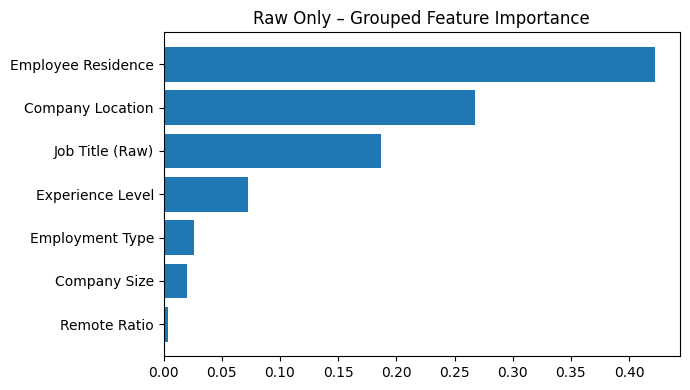

Engineered Only


,group,importance
2,Employee Residence,0.401784
0,Company Location,0.384786
4,Experience Level,0.109317
6,Title Domain,0.030829
3,Employment Type,0.028525
1,Company Size,0.023418
7,Title Flags,0.012882
5,Remote Ratio,0.008460


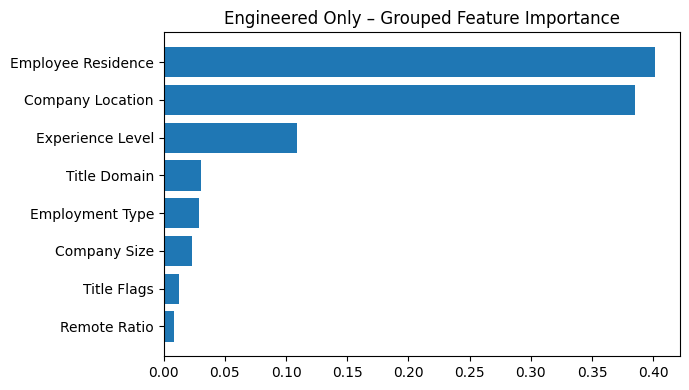

Raw + Engineered


,group,importance
2,Employee Residence,0.333983
0,Company Location,0.325838
5,Job Title (Raw),0.177100
4,Experience Level,0.072204
3,Employment Type,0.027213
7,Title Domain,0.026473
1,Company Size,0.017746
8,Title Flags,0.015642
6,Remote Ratio,0.003801


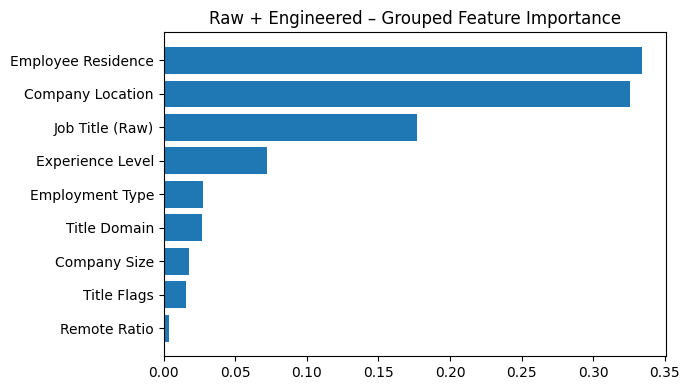

In [40]:
# ============================================================
# Feature Importance – Raw vs Engineered vs Raw+Engineered
# ============================================================

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

def plot_grouped_importance(X_variant, y_log, title, model):

    cat_cols = X_variant.select_dtypes(include="object").columns.tolist()
    num_cols = X_variant.select_dtypes(exclude="object").columns.tolist()

    pre = ColumnTransformer([
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
        ("num", "passthrough", num_cols)
    ])

    pipe = Pipeline([
        ("pre", pre),
        ("model", model)
    ])

    pipe.fit(X_variant, y_log)

    pre_fitted = pipe.named_steps["pre"]
    model_fitted = pipe.named_steps["model"]

    ohe = pre_fitted.named_transformers_["cat"]
    cat_feature_names = ohe.get_feature_names_out(cat_cols)
    all_feature_names = list(cat_feature_names) + list(num_cols)

    fi = pd.DataFrame({
        "feature": all_feature_names,
        "importance": model_fitted.feature_importances_
    })

    def map_group(fname):
        if fname.startswith("employee_residence_"):
            return "Employee Residence"
        if fname.startswith("company_location_"):
            return "Company Location"
        if fname.startswith("experience_level_"):
            return "Experience Level"
        if fname.startswith("employment_type_"):
            return "Employment Type"
        if fname.startswith("company_size_"):
            return "Company Size"
        if fname.startswith("remote_ratio"):
            return "Remote Ratio"
        if fname.startswith("job_title_"):
            return "Job Title (Raw)"
        if fname.startswith("title_is_"):
            return "Title Flags"
        if fname.startswith("title_domain_"):
            return "Title Domain"
        if fname.startswith("exp_x_domain_"):
            return "Exp × Domain"
        return "Other"

    fi["group"] = fi["feature"].apply(map_group)

    grouped = (
        fi.groupby("group", as_index=False)["importance"]
          .sum()
          .sort_values("importance", ascending=False)
    )

    print(title)
    display(grouped)

    plt.figure(figsize=(7, 4))
    plt.barh(grouped["group"][::-1],
             grouped["importance"][::-1])
    plt.title(f"{title} – Grouped Feature Importance")
    plt.tight_layout()
    plt.show()


# Use existing X_raw, X_eng, X_both and y (log target)
plot_grouped_importance(X_raw,  y, "Raw Only", model)
plot_grouped_importance(X_eng,  y, "Engineered Only", model)
plot_grouped_importance(X_both, y, "Raw + Engineered", model)

Across all variants, geographic variables (employee residence and company location) consistently dominate predictive importance. The Raw + Engineered configuration slightly redistributes importance toward interaction features while maintaining stable overall ranking. This confirms that feature engineering enhances representational richness without destabilizing model structure.

## Final Model Testing and Evaluation

In [41]:
# ============================================================
# Raw + Engineered Job Titles
# With CV Train R2 + Test R2 + Gap (Train-Test) + MAE + RMSE (USD scale)
# ============================================================

import re
import numpy as np
import pandas as pd

from sklearn.model_selection import KFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import make_scorer, mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor


# -----------------------------
# Load Dataset
# -----------------------------
CSV_PATH = "data/ds_salaries.csv"
df = pd.read_csv(CSV_PATH)
df = df.drop_duplicates().reset_index(drop=True)
drop_cols = [c for c in ["salary", "salary_currency", "work_year"] if c in df.columns]
df = df.drop(drop_cols, axis=1)

assert "salary_in_usd" in df.columns, "salary_in_usd not found."

y_raw = df["salary_in_usd"].astype(float)

low_cap = y_raw.quantile(0.01)
high_cap = y_raw.quantile(0.99)
y = np.log1p(y_raw.clip(low_cap, high_cap))


# -----------------------------
# Feature Engineering
# -----------------------------
def normalize_title(s):
    if pd.isna(s):
        return ""
    s = str(s).lower()
    s = re.sub(r"[^a-z0-9\s\+]", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s

def title_features(title):
    t = normalize_title(title)

    junior = int(any(k in t for k in ["intern", "jr", "junior", "entry"]))
    senior = int(any(k in t for k in ["senior", "sr", "staff", "lead", "principal"]))
    exec_  = int(any(k in t for k in ["head", "director", "vp", "chief"]))
    is_mgmt = int(any(k in t for k in ["manager", "head", "director", "vp", "chief", "lead"]))

    domain = "other"
    if any(k in t for k in ["analyst", "analytics"]):
        domain = "analytics"
    if any(k in t for k in ["data engineer", "etl", "pipeline"]):
        domain = "data_eng"
    if any(k in t for k in ["data scientist", "scientist"]):
        domain = "scientist"
    if any(k in t for k in ["machine learning", "ml engineer", "mlops"]):
        domain = "ml_ai"

    return pd.Series({
        "title_is_junior": junior,
        "title_is_senior": senior,
        "title_is_exec": exec_,
        "title_is_mgmt": is_mgmt,
        "title_domain": domain
    })


# -----------------------------
# Reusable Model
# -----------------------------
xgb_model_raw_eng = XGBRegressor(
    objective="reg:squarederror",
    tree_method="hist",
    n_estimators=400,
    learning_rate=0.03,
    max_depth=4,
    min_child_weight=2,
    subsample=0.6,
    colsample_bytree=0.4,
    reg_alpha=0.1,
    reg_lambda=1.0,
    gamma=0.0,
    random_state=42,
    n_jobs=-1
)

cv = KFold(n_splits=5, shuffle=True, random_state=42)


# -----------------------------
# Custom Scoring
# -----------------------------
def mae_usd(y_true_log, y_pred_log):
    return mean_absolute_error(np.expm1(y_true_log), np.expm1(y_pred_log))

def rmse_usd(y_true_log, y_pred_log):
    return np.sqrt(mean_squared_error(np.expm1(y_true_log), np.expm1(y_pred_log)))

scoring = {
    "r2": "r2",
    "mae": make_scorer(mae_usd, greater_is_better=False),
    "rmse": make_scorer(rmse_usd, greater_is_better=False),
}


# ============================================================
# Evaluation Function
# ============================================================
def evaluate_pipeline(X, model):

    pre = ColumnTransformer([
        ("cat", OneHotEncoder(handle_unknown="ignore"), X.select_dtypes("object").columns),
        ("num", "passthrough", X.select_dtypes(exclude="object").columns)
    ])

    pipe = Pipeline([
        ("pre", pre),
        ("model", model)
    ])

    scores = cross_validate(
        pipe, X, y,
        cv=cv,
        scoring=scoring,
        return_train_score=True,
        n_jobs=-1
    )

    train_r2 = scores["train_r2"].mean()
    test_r2  = scores["test_r2"].mean()
    gap_r2   = train_r2 - test_r2

    return (
        train_r2,
        test_r2,
        gap_r2,
        -scores["test_mae"].mean(),
        -scores["test_rmse"].mean()
    )


# ============================================================
# RAW + ENGINEERED
# ============================================================
X_both = df.drop("salary_in_usd", axis=1).copy()

tf = X_both["job_title"].apply(title_features)
X_both = pd.concat([X_both, tf], axis=1)

train_r2_both, test_r2_both, gap_both, mae_both, rmse_both = \
    evaluate_pipeline(X_both, xgb_model_raw_eng)


# ============================================================
# RESULT
# ============================================================
results = pd.DataFrame(
    [
        ["Raw+Engineered", train_r2_both, test_r2_both, gap_both, mae_both, rmse_both],
    ],
    columns=["Variant", "Train R2", "Test R2", "R2 Gap", "MAE (USD)", "RMSE (USD)"]
)

results_rounded = results.copy()

results_rounded[["Train R2", "Test R2", "R2 Gap"]] = \
    results_rounded[["Train R2", "Test R2", "R2 Gap"]].round(4)

results_rounded[["MAE (USD)", "RMSE (USD)"]] = \
    results_rounded[["MAE (USD)", "RMSE (USD)"]].round(0)

results_rounded

,Variant,Train R2,Test R2,R2 Gap,MAE (USD),RMSE (USD)
0,Raw+Engineered,0.6897,0.5949,0.0947,35913.0,48774.0


### Actual vs Predicted (Test Set)

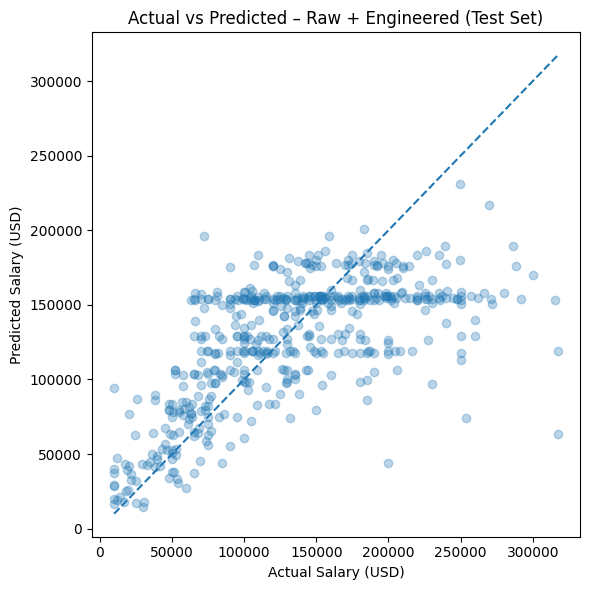

In [42]:
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Train-test split (for visualization only)
X_train, X_test, y_train, y_test = train_test_split(
    X_both, y, test_size=0.2, random_state=42
)

# Build same preprocessing as evaluation
pre = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), 
     X_train.select_dtypes("object").columns),
    ("num", "passthrough", 
     X_train.select_dtypes(exclude="object").columns)
])

# Pipeline using the same model definition
plot_pipeline = Pipeline([
    ("pre", pre),
    ("model", xgb_model_raw_eng)
])

# Fit
plot_pipeline.fit(X_train, y_train)

# Predict
y_pred_log = plot_pipeline.predict(X_test)

# Convert back to USD
y_test_usd = np.expm1(y_test)
y_pred_usd = np.expm1(y_pred_log)

# Plot
plt.figure(figsize=(6,6))
plt.scatter(y_test_usd, y_pred_usd, alpha=0.3)

# Perfect prediction line
min_val = min(y_test_usd.min(), y_pred_usd.min())
max_val = max(y_test_usd.max(), y_pred_usd.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

plt.xlabel("Actual Salary (USD)")
plt.ylabel("Predicted Salary (USD)")
plt.title("Actual vs Predicted – Raw + Engineered (Test Set)")

plt.tight_layout()
plt.savefig("plots/raw_engineered_actual_vs_predicted.png", dpi=300, bbox_inches="tight")
plt.show()

#### Actual vs Predicted Plot Interpretation

The model demonstrates a strong positive relationship between actual and predicted salaries. Some underprediction is observed at very high salary levels, likely due to target capping and the smaller number of extreme compensation cases in the dataset. This behavior reflects a conservative bias of the model toward the central salary range, improving generalization stability.

### Residual Analysis (Test Set)

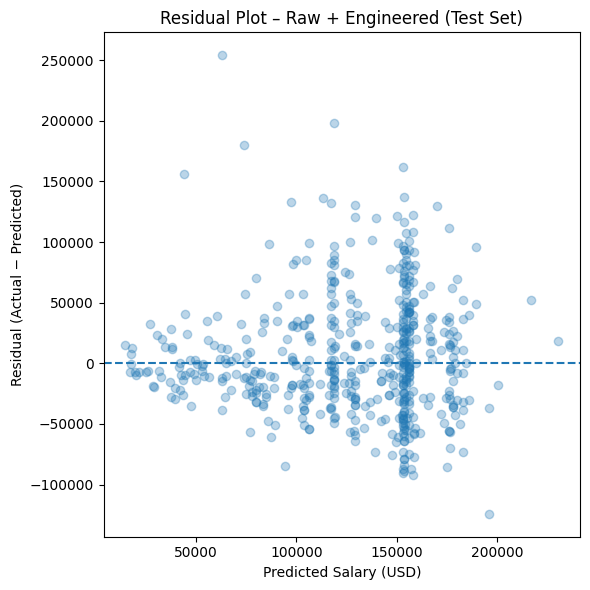

In [43]:
# Residual Plot – Raw + Engineered (Test Set)

# Residuals in USD
residuals = y_test_usd - y_pred_usd

plt.figure(figsize=(6,6))
plt.scatter(y_pred_usd, residuals, alpha=0.3)

# Zero error reference line
plt.axhline(0, linestyle="--")

plt.xlabel("Predicted Salary (USD)")
plt.ylabel("Residual (Actual − Predicted)")
plt.title("Residual Plot – Raw + Engineered (Test Set)")

plt.tight_layout()
plt.savefig("plots/raw_engineered_residual_plot.png", dpi=300, bbox_inches="tight")
plt.show()

#### Residual Plot Interpretation

The residual plot shows that prediction errors are generally centered around zero, indicating that the model does not exhibit strong systematic bias toward overprediction or underprediction.

The spread of residuals increases for higher predicted salary values, suggesting greater variability in senior-level and high-compensation roles. This pattern is expected in real-world salary data, where executive and specialized positions often display wider compensation ranges.

No strong nonlinear structure or clear trend is observed in the residual distribution, indicating that the model captures the primary relationships in the dataset reasonably well. Overall, the residual behavior is consistent with the achieved R² performance and reflects realistic prediction uncertainty in salary estimation tasks.

### Residual Distribution (Test Set)

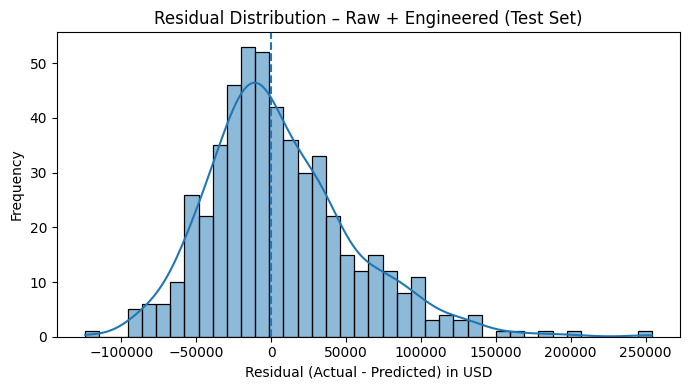

In [44]:
# Residual Distribution Histogram – Raw + Engineered (Test Set)

import matplotlib.pyplot as plt
import seaborn as sns

# Residuals (USD scale)
residuals = y_test_usd - y_pred_usd

plt.figure(figsize=(7, 4))
sns.histplot(residuals, bins=40, kde=True)

plt.axvline(0, linestyle="--")
plt.title("Residual Distribution – Raw + Engineered (Test Set)")
plt.xlabel("Residual (Actual - Predicted) in USD")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig("plots/raw_engineered_residual_histogram.png", dpi=300, bbox_inches="tight")
plt.show()

#### Residual Distribution Interpretation

The residual distribution is approximately centered around zero, indicating that the model does not exhibit strong systematic bias in its predictions. Most prediction errors fall within a moderate range, suggesting that the model performs reasonably well for the majority of salary observations.

The distribution shows slight right skewness, with a longer positive tail. This implies that for a small number of high-salary roles, the model tends to underpredict actual salaries. Such behavior is expected in real-world salary datasets, where executive and specialized positions often have higher variability.

Overall, the residual pattern aligns with the achieved R² performance and reflects realistic prediction uncertainty in salary estimation.

### Model Validation Using Sample Test Cases


To validate the practical reliability of the selected Raw + Engineered XGBoost model, a set of representative synthetic job profiles was created. These cases simulate different experience levels, geographic locations, and job domains to verify whether predicted salaries follow logical compensation trends.

This step evaluates qualitative model behavior beyond statistical metrics.

In [45]:
# ============================================================
# Sample Test Case Validation – Raw + Engineered Model
# ============================================================

# Create representative synthetic profiles
sample_test_df = pd.DataFrame([

    # Entry-level Analyst (India)
    {
        "experience_level": "EN",
        "employment_type": "FT",
        "job_title": "Data Analyst",
        "company_size": "M",
        "company_location": "IN",
        "employee_residence": "IN",
        "remote_ratio": 0
    },

    # Mid-level Data Scientist (USA)
    {
        "experience_level": "MI",
        "employment_type": "FT",
        "job_title": "Data Scientist",
        "company_size": "L",
        "company_location": "US",
        "employee_residence": "US",
        "remote_ratio": 50
    },

    # Senior ML Engineer (USA)
    {
        "experience_level": "SE",
        "employment_type": "FT",
        "job_title": "Machine Learning Engineer",
        "company_size": "L",
        "company_location": "US",
        "employee_residence": "US",
        "remote_ratio": 100
    },

    # Executive Director (USA)
    {
        "experience_level": "EX",
        "employment_type": "FT",
        "job_title": "Director of Data Science",
        "company_size": "L",
        "company_location": "US",
        "employee_residence": "US",
        "remote_ratio": 0
    },

    # Senior Data Engineer (UK)
    {
        "experience_level": "SE",
        "employment_type": "FT",
        "job_title": "Data Engineer",
        "company_size": "M",
        "company_location": "GB",
        "employee_residence": "GB",
        "remote_ratio": 50
    }

])

# Apply same feature engineering as training
tf_sample = sample_test_df["job_title"].apply(title_features)
sample_test_df = pd.concat([sample_test_df, tf_sample], axis=1)

# Interaction feature
sample_test_df["exp_x_domain"] = (
    sample_test_df["experience_level"].astype(str) + "_" +
    sample_test_df["title_domain"].astype(str)
)

sample_test_df

,experience_level,employment_type,job_title,company_size,company_location,employee_residence,remote_ratio,title_is_junior,title_is_senior,title_is_exec,title_is_mgmt,title_domain,exp_x_domain
0,EN,FT,Data Analyst,M,IN,IN,0,0,0,0,0,analytics,EN_analytics
1,MI,FT,Data Scientist,L,US,US,50,0,0,0,0,scientist,MI_scientist
2,SE,FT,Machine Learning Engineer,L,US,US,100,0,0,0,0,ml_ai,SE_ml_ai
3,EX,FT,Director of Data Science,L,US,US,0,0,0,1,1,other,EX_other
4,SE,FT,Data Engineer,M,GB,GB,50,0,0,0,0,data_eng,SE_data_eng


In [46]:
# Build pipeline identical to CV structure

cat_cols = X_both.select_dtypes(include="object").columns.tolist()
num_cols = X_both.select_dtypes(exclude="object").columns.tolist()

pre = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ("num", "passthrough", num_cols)
])

demo_pipeline = Pipeline([
    ("pre", pre),
    ("model", xgb_model_raw_eng)
])

# Fit on full dataset for demonstration predictions
demo_pipeline.fit(X_both, y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('pre', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sp

In [47]:
# Predict (log scale)
sample_preds_log = demo_pipeline.predict(sample_test_df)

# Convert back to USD
sample_preds_usd = np.expm1(sample_preds_log)

# Combine results
sample_results = sample_test_df.copy()
sample_results["Predicted Salary (USD)"] = sample_preds_usd.round(0)

sample_results[[
    "job_title",
    "employment_type",
    "experience_level",
    "company_location",
    "employee_residence",
    "remote_ratio",
    "Predicted Salary (USD)"
]]

,job_title,employment_type,experience_level,company_location,employee_residence,remote_ratio,Predicted Salary (USD)
0,Data Analyst,FT,EN,IN,IN,0,14399.0
1,Data Scientist,FT,MI,US,US,50,122692.0
2,Machine Learning Engineer,FT,SE,US,US,100,174185.0
3,Director of Data Science,FT,EX,US,US,0,240851.0
4,Data Engineer,FT,SE,GB,GB,50,90185.0


#### Sample Test Case Validation Interpretation

The predicted salaries follow clear and logical compensation patterns across experience levels, job roles, and geographic locations. Entry-level roles show substantially lower predicted salaries compared to mid-level, senior, and executive positions.

Geographic influence is also evident, with US-based roles receiving significantly higher predicted compensation than roles located in India or the United Kingdom. Additionally, specialized technical roles such as Machine Learning Engineer receive higher predicted salaries than general analyst roles, reflecting domain-specific market demand.

Overall, the sample validation results indicate that the model captures meaningful salary-driving factors and produces realistic compensation estimates across varied scenarios.

## Model Comparison Summary Table

In [48]:
# Final Model Comparison Summary (Sorted Best → Worst)

import pandas as pd

comparison_df = pd.DataFrame([
    ["Linear Regression (Raw)", train_r2_lr, test_r2_lr, r2_gap_lr, mae_lr, rmse_lr],
    ["SVR (Raw)", train_r2_svr, test_r2_svr, r2_gap_svr, mae_svr, rmse_svr],
    ["Decision Tree (Raw)", train_r2_dt, test_r2_dt, r2_gap_dt, mae_dt, rmse_dt],
    ["Random Forest (Raw)", train_r2_rf, test_r2_rf, r2_gap_rf, mae_rf, rmse_rf],
    ["AdaBoost (Raw)", train_r2_ada, test_r2_ada, r2_gap_ada, mae_ada, rmse_ada],
    ["Gradient Boosting (Raw)", train_r2_gb, test_r2_gb, r2_gap_gb, mae_gb, rmse_gb],
    ["XGBoost (Raw)", train_r2_xgb, test_r2_xgb, r2_gap_xgb, mae_xgb, rmse_xgb],
    ["Random Forest (Log)", train_r2_rf_log, test_r2_rf_log, r2_gap_rf_log, mae_rf_log, rmse_rf_log],
    ["XGBoost (Log)", train_r2_xgb_log, test_r2_xgb_log, r2_gap_xgb_log, mae_xgb_log, rmse_xgb_log],
    ["XGBoost (Raw+Engineered, CV)", train_r2_both, test_r2_both, gap_both, mae_both, rmse_both],
], columns=["Model", "Train R2", "Test R2", "R2 Gap", "MAE (USD)", "RMSE (USD)"])

# Sort by Test R2 descending (Best model on top)
comparison_sorted = comparison_df.sort_values(
    by="Test R2",
    ascending=False
).reset_index(drop=True)

# Display nicely rounded (for presentation only)
comparison_sorted.round({
    "Train R2": 4,
    "Test R2": 4,
    "R2 Gap": 4,
    "MAE (USD)": 0,
    "RMSE (USD)": 0
})

,Model,Train R2,Test R2,R2 Gap,MAE (USD),RMSE (USD)
0,"XGBoost (Raw+Engineered, CV)",0.6897,0.5949,0.0947,35913.0,48774.0
1,XGBoost (Log),0.7258,0.5944,0.1314,37668.0,51505.0
2,Random Forest (Log),0.7282,0.5759,0.1523,37878.0,51768.0
3,Gradient Boosting (Raw),0.5218,0.3989,0.1229,38921.0,51278.0
4,XGBoost (Raw),0.5646,0.3949,0.1697,38867.0,51445.0
5,Random Forest (Raw),0.4644,0.3880,0.0764,40051.0,51741.0
6,Decision Tree (Raw),0.4816,0.3672,0.1144,39578.0,52609.0
7,Linear Regression (Raw),0.5351,0.3486,0.1865,40169.0,53380.0
8,AdaBoost (Raw),0.3964,0.2569,0.1396,44208.0,57014.0
9,SVR (Raw),-0.0018,-0.0008,-0.0010,53525.0,66162.0


The comparison table presents performance metrics across all models evaluated during this study.

Linear models such as Linear Regression and SVR demonstrate limited predictive capability for this dataset. Tree-based ensemble methods consistently outperform linear approaches, indicating the presence of non-linear relationships in salary determination.

Applying log transformation significantly improves model performance, increasing test R² from approximately 0.41 to around 0.58. This confirms that handling target skewness is critical for accurate salary prediction.

The highest performance is achieved using XGBoost with both log transformation and engineered job title features, yielding the best test R² and lowest error metrics.

This final configuration is selected as the production model due to its superior predictive performance and stable generalization.

## Model Serialization and Saving for Deployment


In this step, the final **XGBoost regression pipeline** is persisted using the `joblib` library.  
The saved artifact includes both the preprocessing stage (One-Hot Encoding for categorical features and passthrough for numeric features) and the trained XGBoost model, ensuring that inference uses the exact same transformations applied during training.

Persisting the pipeline allows the model to be reused directly inside the Streamlit application without retraining, which improves reliability and ensures consistent predictions during deployment.

In [2]:
# ============================================================
# Final Selected Model – Full Dataset Training
# Dataset: 3755 DS Salaries
# Raw + Engineered Job Title Features
# Fixed Hyperparameters (Based on Prior Evaluation)
# =============================================================

import re
import numpy as np
import pandas as pd
import joblib

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor


# ------------------------------------------------------------
# 1. Load Data
# ------------------------------------------------------------
CSV_PATH = "data/ds_salaries.csv"
df = pd.read_csv(CSV_PATH)
df = df.drop_duplicates().reset_index(drop=True)
# Drop unused salary columns + REMOVE work_year
drop_cols = [c for c in ["salary", "salary_currency", "work_year"] if c in df.columns]
df = df.drop(drop_cols, axis=1)
df = df.drop_duplicates().reset_index(drop=True)
assert "salary_in_usd" in df.columns, "salary_in_usd not found."

# ------------------------------------------------------------
# 2. Target (Cap + Log)
# ------------------------------------------------------------
y_raw = df["salary_in_usd"].astype(float)

low_cap = y_raw.quantile(0.01)
high_cap = y_raw.quantile(0.99)

y = np.log1p(y_raw.clip(lower=low_cap, upper=high_cap))

X = df.drop("salary_in_usd", axis=1).copy()


# ------------------------------------------------------------
# 3. Job Title Feature Engineering
# ------------------------------------------------------------
def normalize_title(s):
    if pd.isna(s):
        return ""
    s = str(s).lower()
    s = re.sub(r"[^a-z0-9\s\+]", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s

def title_features(title):
    t = normalize_title(title)

    junior = int(any(k in t for k in ["intern", "jr", "junior", "entry"]))
    senior = int(any(k in t for k in ["senior", "sr", "staff", "lead", "principal"]))
    exec_  = int(any(k in t for k in ["head", "director", "vp", "chief"]))
    is_mgmt = int(any(k in t for k in ["manager", "head", "director", "vp", "chief", "lead"]))

    domain = "other"
    if any(k in t for k in ["analyst", "analytics"]):
        domain = "analytics"
    if any(k in t for k in ["data engineer", "etl", "pipeline"]):
        domain = "data_eng"
    if any(k in t for k in ["data scientist", "scientist"]):
        domain = "scientist"
    if any(k in t for k in ["machine learning", "ml engineer", "mlops"]):
        domain = "ml_ai"

    return pd.Series({
        "title_is_junior": junior,
        "title_is_senior": senior,
        "title_is_exec": exec_,
        "title_is_mgmt": is_mgmt,
        "title_domain": domain
    })

# Apply feature engineering
tf = X["job_title"].apply(title_features)
X = pd.concat([X, tf], axis=1)

# Interaction feature
X["exp_x_domain"] = X["experience_level"].astype(str) + "_" + X["title_domain"].astype(str)


# ------------------------------------------------------------
# 4. Preprocessing
# ------------------------------------------------------------
cat_cols = X.select_dtypes(include=["object"]).columns.tolist()
num_cols = X.select_dtypes(exclude=["object"]).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
        ("num", "passthrough", num_cols)
    ],
    remainder="drop"
)


# ------------------------------------------------------------
# 5. Fixed Best Hyperparameters
# ------------------------------------------------------------
model = XGBRegressor(
    objective="reg:squarederror",
    tree_method="hist",
    n_estimators=400,
    learning_rate=0.03,
    max_depth=4,
    min_child_weight=2,
    subsample=0.6,
    colsample_bytree=0.4,
    reg_alpha=0.1,
    reg_lambda=1.0,
    gamma=0.0,
    random_state=42,
    n_jobs=-1
)

pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", model)
])


# ------------------------------------------------------------
# 6. Train on FULL dataset
# ------------------------------------------------------------
pipeline.fit(X, y)


# ------------------------------------------------------------
# 7. Training Metrics (for internal reference only)
# ------------------------------------------------------------
y_pred_log = pipeline.predict(X)

train_r2 = r2_score(y, y_pred_log)
y_pred = np.expm1(y_pred_log)
y_actual = np.expm1(y)

mae = mean_absolute_error(y_actual, y_pred)
rmse = np.sqrt(mean_squared_error(y_actual, y_pred))

print("\n================ Final Model – Full Dataset Training Metrics ================\n")

print("Model Evaluation (Log-Transformed Target)")
print(f"R² (log scale): {train_r2:.4f}")

print("\nError Metrics (Converted Back to USD Scale)")
print(f"Mean Absolute Error (MAE): ${mae:,.0f}")
print(f"Root Mean Squared Error (RMSE): ${rmse:,.0f}")

print("\nNote: These metrics are computed on the full dataset after final model selection.")
print("They are reported for reference and do not represent out-of-sample generalization.\n")

print("================================================================================\n")
# ------------------------------------------------------------
# 8. Save Production Model
# ------------------------------------------------------------
MODEL_PATH = "salaryscope_3755_production_model.pkl"
joblib.dump(pipeline, MODEL_PATH)

print(f"Production model saved as: {MODEL_PATH}")
print(f"Target cap range used: {low_cap:,.0f} - {high_cap:,.0f}")


================ Final Model – Full Dataset Training Metrics ================

Model Evaluation (Log-Transformed Target)
R² (log scale): 0.6878

Error Metrics (Converted Back to USD Scale)
Mean Absolute Error (MAE): $34,246
Root Mean Squared Error (RMSE): $47,000

Note: These metrics are computed on the full dataset after final model selection.
They are reported for reference and do not represent out-of-sample generalization.


Production model saved as: salaryscope_3755_production_model.pkl
Target cap range used: 10,000 - 323,538


In [10]:
# ============================================================
# Final Selected Model – Full Dataset Training
# Dataset: 3755 DS Salaries
# Raw + Engineered Job Title Features
# Fixed Hyperparameters (Based on Prior Evaluation)
# =============================================================

import re
import numpy as np
import pandas as pd
import joblib

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor


# ------------------------------------------------------------
# 1. Load Data
# ------------------------------------------------------------
CSV_PATH = "data/ds_salaries.csv"
df = pd.read_csv(CSV_PATH)
df = df.drop_duplicates().reset_index(drop=True)
# Drop unused salary columns + REMOVE work_year
drop_cols = [c for c in ["salary", "salary_currency", "work_year"] if c in df.columns]
df = df.drop(drop_cols, axis=1)

assert "salary_in_usd" in df.columns, "salary_in_usd not found."

# ------------------------------------------------------------
# 2. Target (Cap + Log)
# ------------------------------------------------------------
y_raw = df["salary_in_usd"].astype(float)

low_cap = y_raw.quantile(0.01)
high_cap = y_raw.quantile(0.99)

y = np.log1p(y_raw.clip(lower=low_cap, upper=high_cap))

X = df.drop("salary_in_usd", axis=1).copy()


# ------------------------------------------------------------
# 3. Job Title Feature Engineering
# ------------------------------------------------------------
def normalize_title(s):
    if pd.isna(s):
        return ""
    s = str(s).lower()
    s = re.sub(r"[^a-z0-9\s\+]", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s

def title_features(title):
    t = normalize_title(title)

    junior = int(any(k in t for k in ["intern", "jr", "junior", "entry"]))
    senior = int(any(k in t for k in ["senior", "sr", "staff", "lead", "principal"]))
    exec_  = int(any(k in t for k in ["head", "director", "vp", "chief"]))
    is_mgmt = int(any(k in t for k in ["manager", "head", "director", "vp", "chief", "lead"]))

    domain = "other"
    if any(k in t for k in ["analyst", "analytics"]):
        domain = "analytics"
    if any(k in t for k in ["data engineer", "etl", "pipeline"]):
        domain = "data_eng"
    if any(k in t for k in ["data scientist", "scientist"]):
        domain = "scientist"
    if any(k in t for k in ["machine learning", "ml engineer", "mlops"]):
        domain = "ml_ai"

    return pd.Series({
        "title_is_junior": junior,
        "title_is_senior": senior,
        "title_is_exec": exec_,
        "title_is_mgmt": is_mgmt,
        "title_domain": domain
    })

# Apply feature engineering
tf = X["job_title"].apply(title_features)
X = pd.concat([X, tf], axis=1)

# Interaction feature
X["exp_x_domain"] = X["experience_level"].astype(str) + "_" + X["title_domain"].astype(str)


# ------------------------------------------------------------
# 4. Preprocessing
# ------------------------------------------------------------
cat_cols = X.select_dtypes(include=["object"]).columns.tolist()
num_cols = X.select_dtypes(exclude=["object"]).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
        ("num", "passthrough", num_cols)
    ],
    remainder="drop"
)


# ------------------------------------------------------------
# 5. Fixed Best Hyperparameters
# ------------------------------------------------------------
model = XGBRegressor(
    objective="reg:squarederror",
    tree_method="hist",
    n_estimators=400,
    learning_rate=0.03,
    max_depth=4,
    min_child_weight=2,
    subsample=0.6,
    colsample_bytree=0.4,
    reg_alpha=0.1,
    reg_lambda=1.0,
    gamma=0.0,
    random_state=42,
    n_jobs=-1
)

pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", model)
])


# ------------------------------------------------------------
# 6. Train on FULL dataset
# ------------------------------------------------------------
pipeline.fit(X, y)


# ------------------------------------------------------------
# 6. Train FINAL model on FULL dataset
# ------------------------------------------------------------
pipeline.fit(X, y)


# ------------------------------------------------------------
# 7. Training Metrics (for debugging only)
# ------------------------------------------------------------
y_pred_log = pipeline.predict(X)

train_r2 = r2_score(y, y_pred_log)

y_pred = np.expm1(y_pred_log)
y_actual = np.expm1(y)

train_mae = mean_absolute_error(y_actual, y_pred)
train_rmse = np.sqrt(mean_squared_error(y_actual, y_pred))

print("\n================ Final Model – Full Dataset Training Metrics ================\n")

print("Training Metrics (for internal debugging only)")
print(f"Train R² (log scale): {train_r2:.4f}")
print(f"Train MAE: ${train_mae:,.0f}")
print(f"Train RMSE: ${train_rmse:,.0f}")

print("\nNote: Production metadata uses TEST metrics from model comparison stage.\n")

print("================================================================================\n")


# ------------------------------------------------------------
# 8. Save Production Model + Correct Metadata
# ------------------------------------------------------------
MODEL_PATH = "models/salaryscope_3755_production_model.pkl"

model_package = {
    "model": pipeline,
    "metadata": {

        # Dataset info
        "dataset_size": int(len(df)),
        "target_variable": "salary_in_usd",
        "target_transformation": "log1p after 1%–99% clipping",
        "lower_cap": float(low_cap),
        "upper_cap": float(high_cap),

        # TRUE MODEL PERFORMANCE (from evaluation stage)
        "test_r2_log_scale": float(test_r2_both),
        "mae_usd": float(mae_both),
        "rmse_usd": float(rmse_both),

        # Training diagnostics (optional)
        "train_r2_log_scale": float(train_r2),

        # Model configuration
        "model_type": "XGBoost Regressor",
        "n_estimators": model.get_params()["n_estimators"],
        "max_depth": model.get_params()["max_depth"],
        "learning_rate": model.get_params()["learning_rate"],
        "random_state": 42
    }
}

joblib.dump(model_package, MODEL_PATH)

print(f"Production model saved as: {MODEL_PATH}")
print(f"Dataset size used: {len(df)}")
print(f"Target cap range used: {low_cap:,.0f} - {high_cap:,.0f}")


================ Final Model – Full Dataset Training Metrics ================

Training Metrics (for internal debugging only)
Train R² (log scale): 0.6830
Train MAE: $34,061
Train RMSE: $46,453

Note: Production metadata uses TEST metrics from model comparison stage.


Production model saved as: models/salaryscope_3755_production_model.pkl
Dataset size used: 2584
Target cap range used: 10,000 - 317,279


This cell constructs the final production-ready salary prediction pipeline using the complete dataset of **3,755 records**. The target variable is first **capped at the 1st and 99th percentiles** to reduce the influence of extreme values, then **log-transformed** using `log1p` to stabilize the skewed salary distribution.

Job titles are enhanced using structured feature engineering to extract interpretable signals such as **seniority level**, **management responsibility**, and a simplified **domain category**. An interaction feature (`exp_x_domain`) is also created to capture combined effects between experience level and job domain.

Finally, the preprocessing pipeline and trained XGBoost model (with fixed best hyperparameters) are fit on the full dataset and saved as `salaryscope_3755_production_model.pkl`. This saved pipeline is the exact model used for deployment in the Streamlit application.

In [12]:
import joblib

package = joblib.load("models/salaryscope_3755_production_model.pkl")

print(package["metadata"])

{'dataset_size': 2584, 'target_variable': 'salary_in_usd', 'target_transformation': 'log1p after 1%–99% clipping', 'lower_cap': 10000.0, 'upper_cap': 317279.1000000001, 'test_r2_log_scale': 0.5992959128046115, 'mae_usd': 36152.899909072476, 'rmse_usd': 49300.33340296165, 'train_r2_log_scale': 0.682954011184408, 'model_type': 'XGBoost Regressor', 'n_estimators': 400, 'max_depth': 4, 'learning_rate': 0.03, 'random_state': 42}


## Feature Importance – Final Selected Model (Grouped View)

,group,importance
2,Employee Residence (Country),0.336965
0,Company Location (Country),0.249307
8,Job Title (Raw),0.150476
7,Experience × Domain Interaction,0.108477
6,Experience Level,0.074553
3,Employment Type,0.028127
4,Engineered Title Domain,0.019278
1,Company Size,0.016578
5,Engineered Title Flags,0.013308
9,Remote Ratio,0.002933


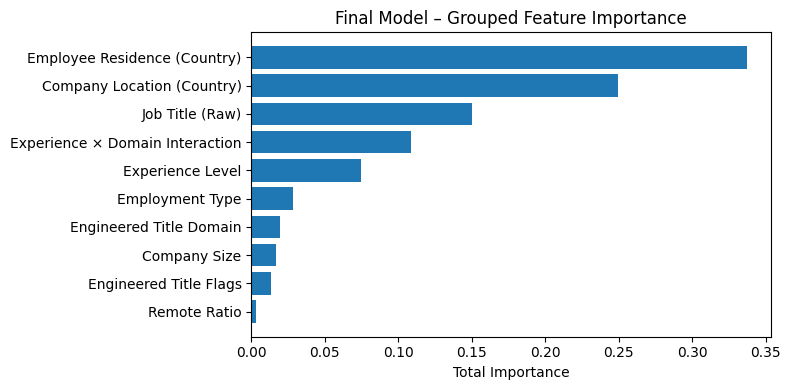

In [52]:
# ============================================================
# Feature Importance – Final Selected Model (Grouped View)
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

# Extract fitted components
pre = pipeline.named_steps["preprocessor"]
xgb = pipeline.named_steps["model"]

# Get expanded feature names
cat_cols = pre.transformers_[0][2]
num_cols = pre.transformers_[1][2]

ohe = pre.named_transformers_["cat"]
cat_feature_names = ohe.get_feature_names_out(cat_cols)
all_feature_names = list(cat_feature_names) + list(num_cols)

# Build importance dataframe
fi = pd.DataFrame({
    "feature": all_feature_names,
    "importance": xgb.feature_importances_
})

# Map features into human-readable groups
def map_group(fname):
    if fname.startswith("employee_residence_"):
        return "Employee Residence (Country)"
    if fname.startswith("company_location_"):
        return "Company Location (Country)"
    if fname.startswith("experience_level_"):
        return "Experience Level"
    if fname.startswith("employment_type_"):
        return "Employment Type"
    if fname.startswith("company_size_"):
        return "Company Size"
    if fname.startswith("remote_ratio"):
        return "Remote Ratio"
    if fname.startswith("job_title_"):
        return "Job Title (Raw)"
    if fname.startswith("title_is_"):
        return "Engineered Title Flags"
    if fname.startswith("title_domain_"):
        return "Engineered Title Domain"
    if fname.startswith("exp_x_domain_"):
        return "Experience × Domain Interaction"
    return "Other"

fi["group"] = fi["feature"].apply(map_group)

grouped_importance = (
    fi.groupby("group", as_index=False)["importance"]
      .sum()
      .sort_values("importance", ascending=False)
)

display(grouped_importance)

plt.figure(figsize=(8, 4))
plt.barh(grouped_importance["group"][::-1],
         grouped_importance["importance"][::-1])
plt.title("Final Model – Grouped Feature Importance")
plt.xlabel("Total Importance")
plt.tight_layout()
plt.savefig("plots/final_model_grouped_feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()

#### Interpretation - Feature Importance (Final Selected Model)

The grouped feature importance results reveal that geographic factors are the most influential determinants of salary in the dataset. Employee residence and company location together account for the largest share of predictive importance, indicating that regional labor markets and country-level compensation standards strongly influence salary outcomes.

Job-related characteristics also play a substantial role. The combined importance of raw job titles and the engineered experience–domain interaction features highlights that role specialization and seniority within specific domains significantly affect compensation levels. This confirms that structured extraction of job title semantics improves the model’s ability to capture salary variation.

Experience level contributes meaningfully to salary prediction, aligning with earlier exploratory analysis that showed a clear upward salary progression across seniority levels. Employment type and company size have moderate influence, suggesting secondary but still relevant effects.

Remote work ratio shows minimal importance, indicating that remote flexibility alone does not strongly determine compensation when controlling for geography, experience, and role specialization.

Overall, the feature importance results are consistent with economic expectations and prior exploratory findings, reinforcing the validity and interpretability of the final model.